# Getting Started

$$\def\RR{\mathbb{R}}
\def\NN{\mathbb{N}}
\def\ZZ{\mathbb{Z}}
\def\I{\mathbf{I}}
\def\0{\mathbf{0}}
\def\1{\mathbf{1}}
\def\q{\mathbf{q}}
\def\u{\mathbf{u}}
\def\z{\mathbf{z}}
\def\d{\mathbf{d}}
\def\f{\mathbf{f}}
\def\s{\mathbf{s}}
\def\Q{\mathbf{Q}}
\def\U{\mathbf{U}}
\def\Z{\mathbf{Z}}
\def\Op{\mathbf{f}}
\def\Ophat{\hat{\mathbf{f}}}
\def\c{\mathbf{c}}
\def\A{\mathbf{A}}
\def\H{\mathbf{H}}
\def\G{\mathbf{G}}
\def\B{\mathbf{B}}
\def\N{\mathbf{N}}
\def\v{\mathbf{v}}
\def\w{\mathbf{w}}
\def\V{\mathbf{V}}
\def\W{\mathbf{W}}
\def\Vr{\mathbf{V}_{\!r}}
\def\Wr{\mathbf{W}_{\!r}}
\def\qhat{\hat{\mathbf{q}}}
\def\zhat{\hat{\mathbf{z}}}
\def\fhat{\hat{\mathbf{f}}}
\def\Qhat{\hat{\mathbf{Q}}}
\def\Zhat{\hat{\mathbf{Z}}}
\def\chat{\hat{\mathbf{c}}}
\def\Ahat{\hat{\mathbf{A}}}
\def\Hhat{\hat{\mathbf{H}}}
\def\Ghat{\hat{\mathbf{G}}}
\def\Bhat{\hat{\mathbf{B}}}
\def\Nhat{\hat{\mathbf{N}}}
\def\D{\mathbf{D}}
\def\ohat{\hat{\mathbf{o}}}
\def\Ohat{\hat{\mathbf{O}}}
\def\bfmu{\boldsymbol{\mu}}
\def\bfGamma{\boldsymbol{\Gamma}}
\def\bfPhi{\boldsymbol{\Phi}}
\def\bfSigma{\boldsymbol{\Sigma}}
\def\bfPsi{\boldsymbol{\Psi}}
\def\bfLambda{\boldsymbol{\Lambda}}
\def\bfxi{\boldsymbol{\xi}}
\def\trp{{^{\mathsf{T}}}}
\def\ddt{\frac{\textrm{d}}{\textrm{d}t}}
\def\ddqhat{\frac{\partial}{\partial\qhat}}
\def\mean{\operatorname{mean}}
\def\std{\operatorname{std}}
\def\argmin{\operatorname{argmin}}$$

The `opinf` package constructs reduced-order models for large dynamical systems.
Such systems often arise from the numerical solution of partial differentials equations.
In this introductory tutorial, we use operator inference (OpInf) to learn a reduced-order model for a simple heat equation.
This is a simplified version of the first numerical example in {cite}`peherstorfer2016opinf`.

## Problem Statement

:::{admonition} Governing Equations
:class: note

For the spatial domain $\Omega = [0,L]\subset \RR$ and the time domain $[t_0,t_f]\subset\RR$, consider the one-dimensional heat equation with homogeneous Dirichlet boundary conditions:

$$
\begin{aligned}
    &\frac{\partial}{\partial t} q(x,t) = \frac{\partial^2}{\partial x^2}q(x,t)
    & x &\in\Omega,\quad t\in(t_0,t_f],
    \\
    &q(0,t) = q(L,t) = 0
    & t &\in [t_0,t_f],
    \\
    &q(x,t_0) = q_{0}(x)
    & x &\in \Omega.
\end{aligned}
$$

This is a model for a one-dimensional rod that conducts heat.
The unknown state variable $q(x,t)$ represents the temperature of the rod at location $x$ and time $t$; the temperature at the ends of the rod are fixed at $0$ and heat is allowed to flow out of the rod at the ends.
:::

:::{admonition} Objective
:class: note

Construct a low-dimensional system of ordinary differential equations, called the _reduced-order model_ (ROM), which can be solved rapidly to produce approximate solutions $q(x, t)$ to the partial differential equation given above. We will use OpInf to learn the ROM from high-fidelity data for one choice of initial condition $q_0(x)$ and test its performance on new initial conditions.
:::

We will make use of {mod}`numpy`, {mod}`scipy`, and {mod}`matplotlib` from the standard Python scientific stack, which are all automatically installed when `opinf` is [installed](../opinf/installation.md).
The {mod}`pandas` library is also used later to consolidate and report results.
We will also use {mod} `pathlib` to properly determine the path to the stored data in this package.

In [1]:
import pathlib, os
import numpy as np
import pandas as pd
import scipy.sparse
import scipy.integrate
import scipy.linalg as la
import matplotlib.pyplot as plt

import opinf

opinf.utils.mpl_config()

## Training Data

We begin by generating training data through a traditional numerical method.
A spatial discretization of the governing equations with $n$ degrees of freedom via finite differences or the finite element method leads to a linear semi-discrete system of $n$ ordinary differential equations,

$$
\begin{aligned}
    \ddt\q(t) = \A\q(t),
    \qquad
    \q(0) = \q_0,
\end{aligned}
$$ (eq_basics_fom)

where $\q:\RR\to\RR^n$, $\A\in\RR^{n\times n}$, and $\q_0\in\RR^n$.
For this tutorial, we use central finite differences to construct this system.

:::{dropdown} Discretization details

For a given $n\in\NN$, let $\{x\}_{i=0}^{n+1}$ be an equidistant grid of $n+2$ points on $\Omega$, i.e.,

$$
\begin{aligned}
    0 &= x_0 < x_1 < \cdots < x_n < x_{n+1} = L
    &
    &\text{and}
    &
    x_{i+1} - x_{i} &= \delta x := \frac{L}{n+1},\quad i=1,\ldots,n-1.
\end{aligned}
$$

The boundary conditions prescribe $q(x_0,t) = q(x_{n+1},t) = 0$.
Our goal is to compute $q(x, t)$ at the interior spatial points $x_{1}, x_{2}, \ldots, x_{n}$ for various $t \in [t_0,t_f].$ That is, we wish to compute the state vector

$$
\begin{aligned}
    \q(t)
    = \left[\begin{array}{c}
        q(x_1,t) \\ \vdots \\ q(x_n,t)
    \end{array}\right]\in\RR^n.
\end{aligned}
$$

Introducing a central finite difference approximation for the spatial derivative,

$$
\begin{aligned}
    \frac{\partial^2}{\partial x^2}q(x,t)
    &\approx \frac{q(x-\delta x,t) - 2q(x,t) + q(x+\delta x,t)}{(\delta x)^2},
\end{aligned}
$$

yields the semi-discrete linear system

$$
\begin{aligned}
    \ddt\q(t) = \A\q(t),
    \qquad
    \q(0) = \q_0,
\end{aligned}
$$

where

$$
\begin{aligned}
    \A &= \frac{1}{(\delta x)^2}\left[\begin{array}{ccccc}
        -2 & 1 & & & \\
        1 & -2 & 1 & & \\
        & \ddots & \ddots & \ddots & \\
        & & 1 & -2 & 1 \\
        & & & 1 & -2 \\
    \end{array}\right] \in\RR^{n\times n},
    &
    \q_0 &= \left[\begin{array}{c}
    q_{0}(x_{1}) \\ q_{0}(x_{2}) \\ \vdots \\ q_{0}(x_{n-1}) \\ q_{0}(x_{n})
    \end{array}\right] \in\RR^{n}.
\end{aligned}
$$

:::

The system {eq}`eq_basics_fom` is called the _full-order model_ (FOM) or the _high-fidelity model_. The computational complexity of solving {eq}`eq_basics_fom` depends on the dimension $n$, which must often be large in order for $\q(t)$ to approximate $q(x,t)$ well over the spatial grid. Our goal is to construct a ROM that approximates the FOM, but whose computational complexity only depends on some smaller dimension $r \ll n$.

:::{admonition} No FOM? No Problem.
:class: important

One key advantage of OpInf is that, because it learns a ROM from data alone, direct access to a FOM is not required.
In this tutorial, we explicitly construct a FOM, but in practice, we only need the following:
1. Solution data to learn from, and
2. Some knowledge of the structure of the governing equations.
:::

For this demo, we import data from a different file that represents solutions to the system of equations with the initial condition

$$
\begin{aligned}
    q_{0}(x) = x(1 - x),
\end{aligned}
$$

and record the solution every $\delta t = 0.0025$ time units.
This results in $k = 401$ state snapshots ($400$ time steps after the initial condition), which are organized into the _snapshot matrix_ $\Q\in\RR^{n\times k}$, where the $j$-th column is the solution trajectory at time $t_j$:

$$
\begin{aligned}
    \Q = \left[\begin{array}{ccc}
        && \\
        \q_{0} & \cdots & \q_{k-1}
        \\ &&
    \end{array}\right] \in\RR^{n\times k},
    \qquad
    \q_{j} := \q(t_j) \in\RR^{n},\quad j = 0, \ldots, k-1.
\end{aligned}
$$

Note that the initial condition $\q_{0}$ is included as a column in the snapshot matrix.

We now import the saved data into the variable `Q`:

In [2]:
BASE_DIR = pathlib.Path(os.getcwd()).resolve().parents[1]
filepath = BASE_DIR / "data" / "basic_training_data.h5"

with opinf.utils.hdf5_loadhandle(filepath) as h5file:
    t = h5file["t"][:]
    Q = h5file["Q"][:]

x_all = np.linspace(0 , 1, Q.shape[0]+2)
x = x_all[1:-1]
dt = t[1] - t[0]

For convenience, we define the initial conditions, $q_0$, as `q0`:

In [3]:
q0 = Q[:, 0]

Next, we visualize the snapshots to get a sense of how the model looks qualitatively.

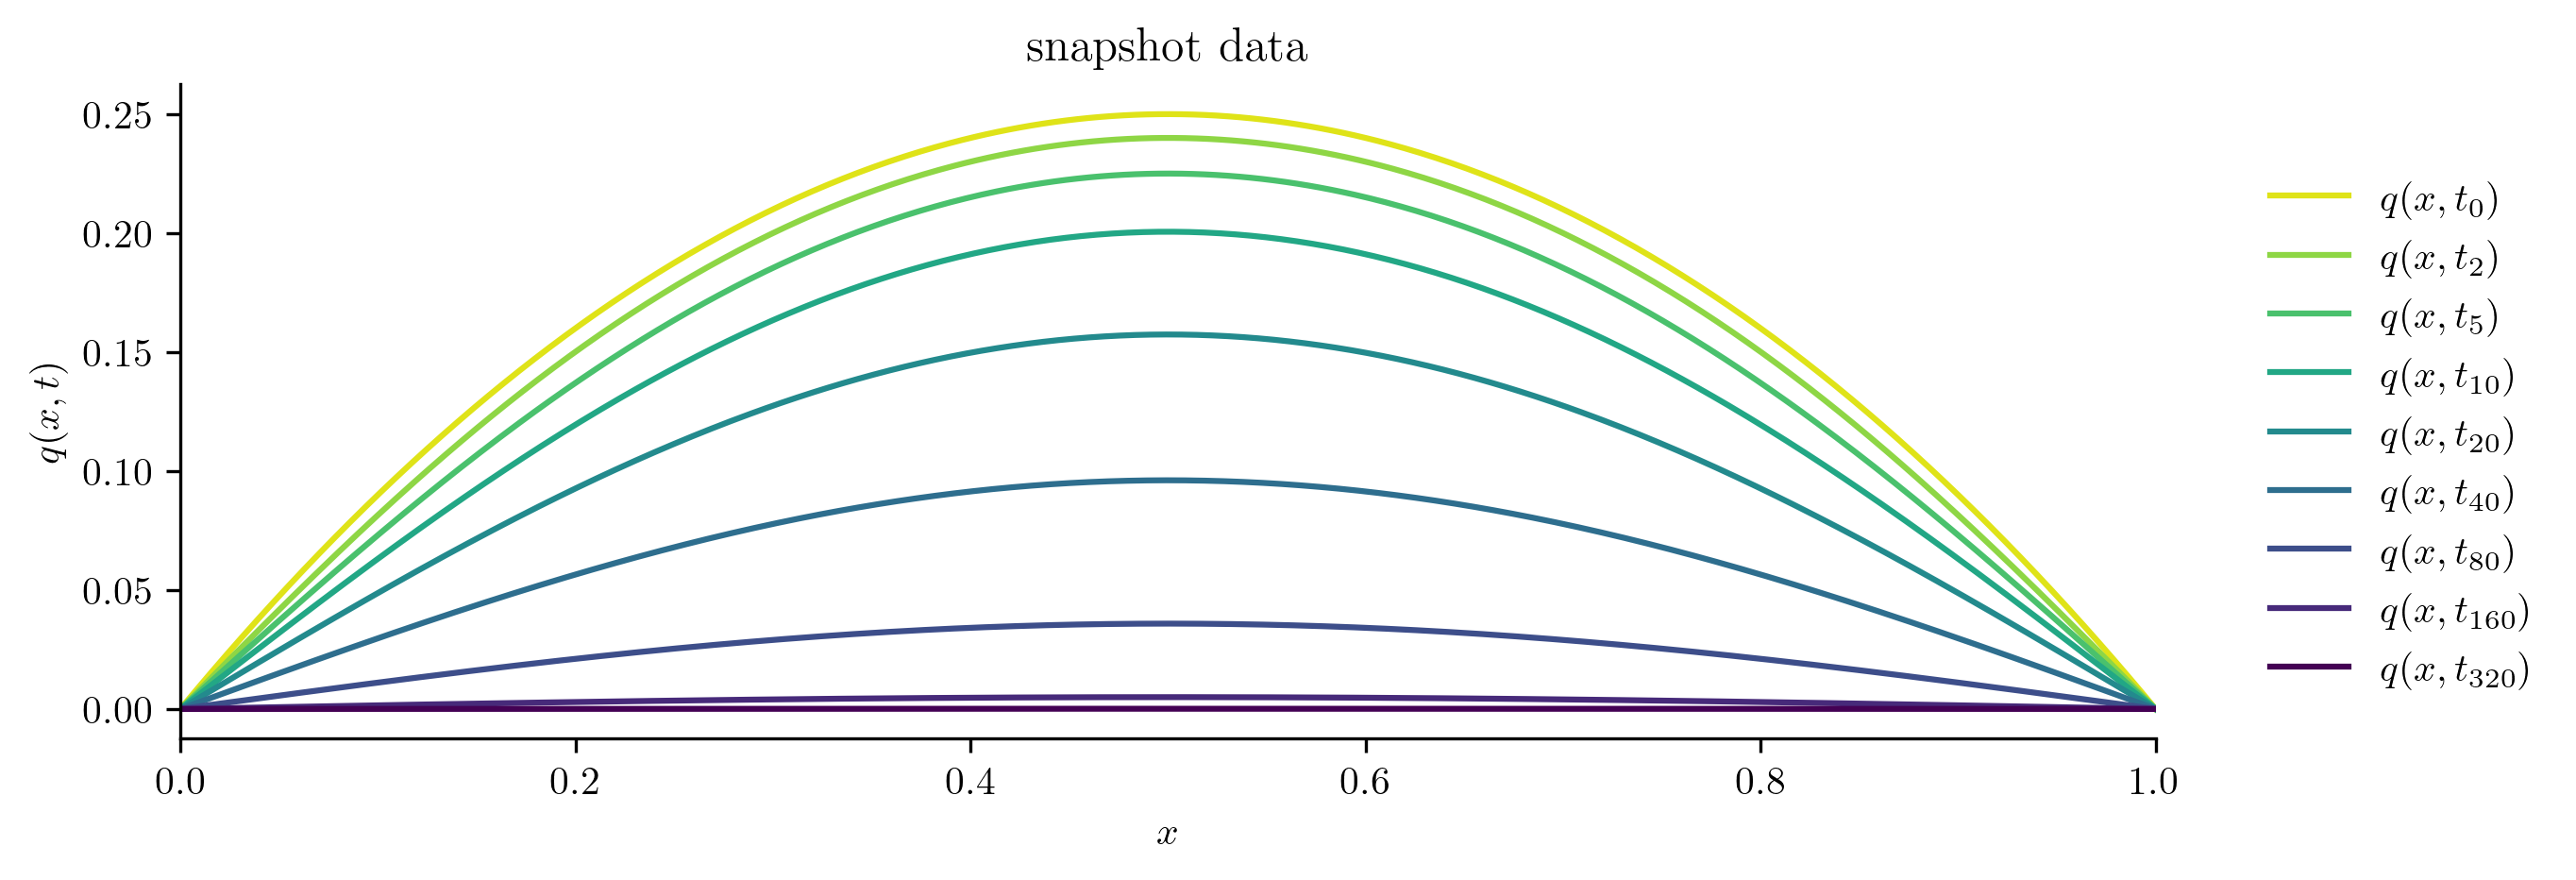

In [4]:
def plot_heat_data(Z, title, ax=None):
    """Visualize temperature data in space and time."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    # Plot a few snapshots over the spatial domain.
    sample_columns = [0, 2, 5, 10, 20, 40, 80, 160, 320]
    color = iter(plt.cm.viridis_r(np.linspace(0.05, 1, len(sample_columns))))

    leftBC, rightBC = [0], [0]
    for j in sample_columns:
        q_all = np.concatenate([leftBC, Z[:, j], rightBC])
        ax.plot(x_all, q_all, color=next(color), label=rf"$q(x,t_{{{j}}})$")

    ax.set_xlim(x_all[0], x_all[-1])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$q(x,t)$")
    ax.legend(loc=(1.05, 0.05))
    ax.set_title(title)

plot_heat_data(Q, "snapshot data")

## Operator Inference

At this point, we have gathered some training data by simulating the FOM.
We also have an initial condition and a time domain.

| Name | Symbol | Code Variable |
| :--- | :----: | :------------ |
| State snapshots | $\Q$ | `Q` |
| Initial state | $\q_0$ | `q0` |
| Time domain | $[t_0,t_f]$ | `t` |

Our task now is to construct a low-dimensional system whose solutions can be used as approximate solutions to the PDE.
Below we show the overall process, then explain each piece that happens under the hood.

In [5]:
import opinf

# Define the reduced-order model.
rom = opinf.ROM(
    basis=opinf.basis.PODBasis(cumulative_energy=0.9999),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel(
        operators="A",
        solver=opinf.lstsq.L2Solver(regularizer=1e-8),
    ),
)

# Calibrate the reduced-order model to data.
rom.fit(Q)

# Solve the reduced-order model.
with opinf.utils.TimedBlock("Reduced-order solve"):
    Q_ROM = rom.predict(q0, t, method="BDF", max_step=dt)

# Compute the relative error of the ROM solution.
opinf.post.frobenius_error(Q, Q_ROM)[1]

Reduced-order solve...done in 0.06 s.


np.float64(0.001052442178977764)

### Data Compression

Our first task is to construct a low-dimensional representation of the FOM state $\q(t)\in\RR^{n}$, denoted $\qhat(t)\in\RR^r$.
A ROM is a system of equations that acts on the reduced state $\qhat(t)$.
The integer $r$ is the dimension of the ROM: if $r \ll n$, we can expect to be able to solve the ROM much faster than we can solve the FOM.

The relationship between $\q(t)$ and $\qhat(t)$ helps dictate the structure of the ROM and allows us to compress the state snapshots $\q_0,\ldots,\q_{k-1}\in\RR^{n}$ to low-dimensional representations $\qhat_0,\ldots,\qhat_{k-1}\in\RR^{r}$ that are used to calibrate the ROM.
Tools for defining low-dimensional approximations of high-dimensional states are defined in {mod}`opinf.basis`.

For this problem, we use a linear approximation for $\q(t)$:

$$
\begin{aligned}
    \q(t)
    \approx \Vr\qhat(t).
\end{aligned}
$$

The matrix $\Vr\in\RR^{n\times r}$ is called a _basis matrix_ and its columns are called _basis vectors_.
We typically have $\Vr\trp\Vr = \I$, i.e., the basis vectors form an orthonormal set.
Note that the product $\Vr\qhat(t)$ is a linear combination of the basis vectors, so $\q(t)$ can only be approximated well if it is within or near the span of the basis vectors.

We choose $\Vr$ using proper orthogonal decomposition (POD), which is based on the singular value decomposition (SVD) of samples of $\q(t)$.
The singular values give some guidance on choosing an appropriate ROM dimension $r$.
Fast singular value decay is a good sign that a ROM may be successful with this kind of data; if the singular values do not decay quickly, then a large $r$ may be required to capture the behavior of the system.
Below, we initialize a {class}`opinf.basis.PODBasis` object with the following criteria for selecting $r$: choose the smallest $r$ such that we capture over $99.9999\%$ of the [cumulative energy](#sec:api-basis-dimselect) of the system.


PODBasis
  full_state_dimension:    512
  reduced_state_dimension: 2
  cumulative energy: 99.999898%
  residual energy:   1.0153e-06
  401 basis vectors available
  SVD solver: scipy.linalg.svd()


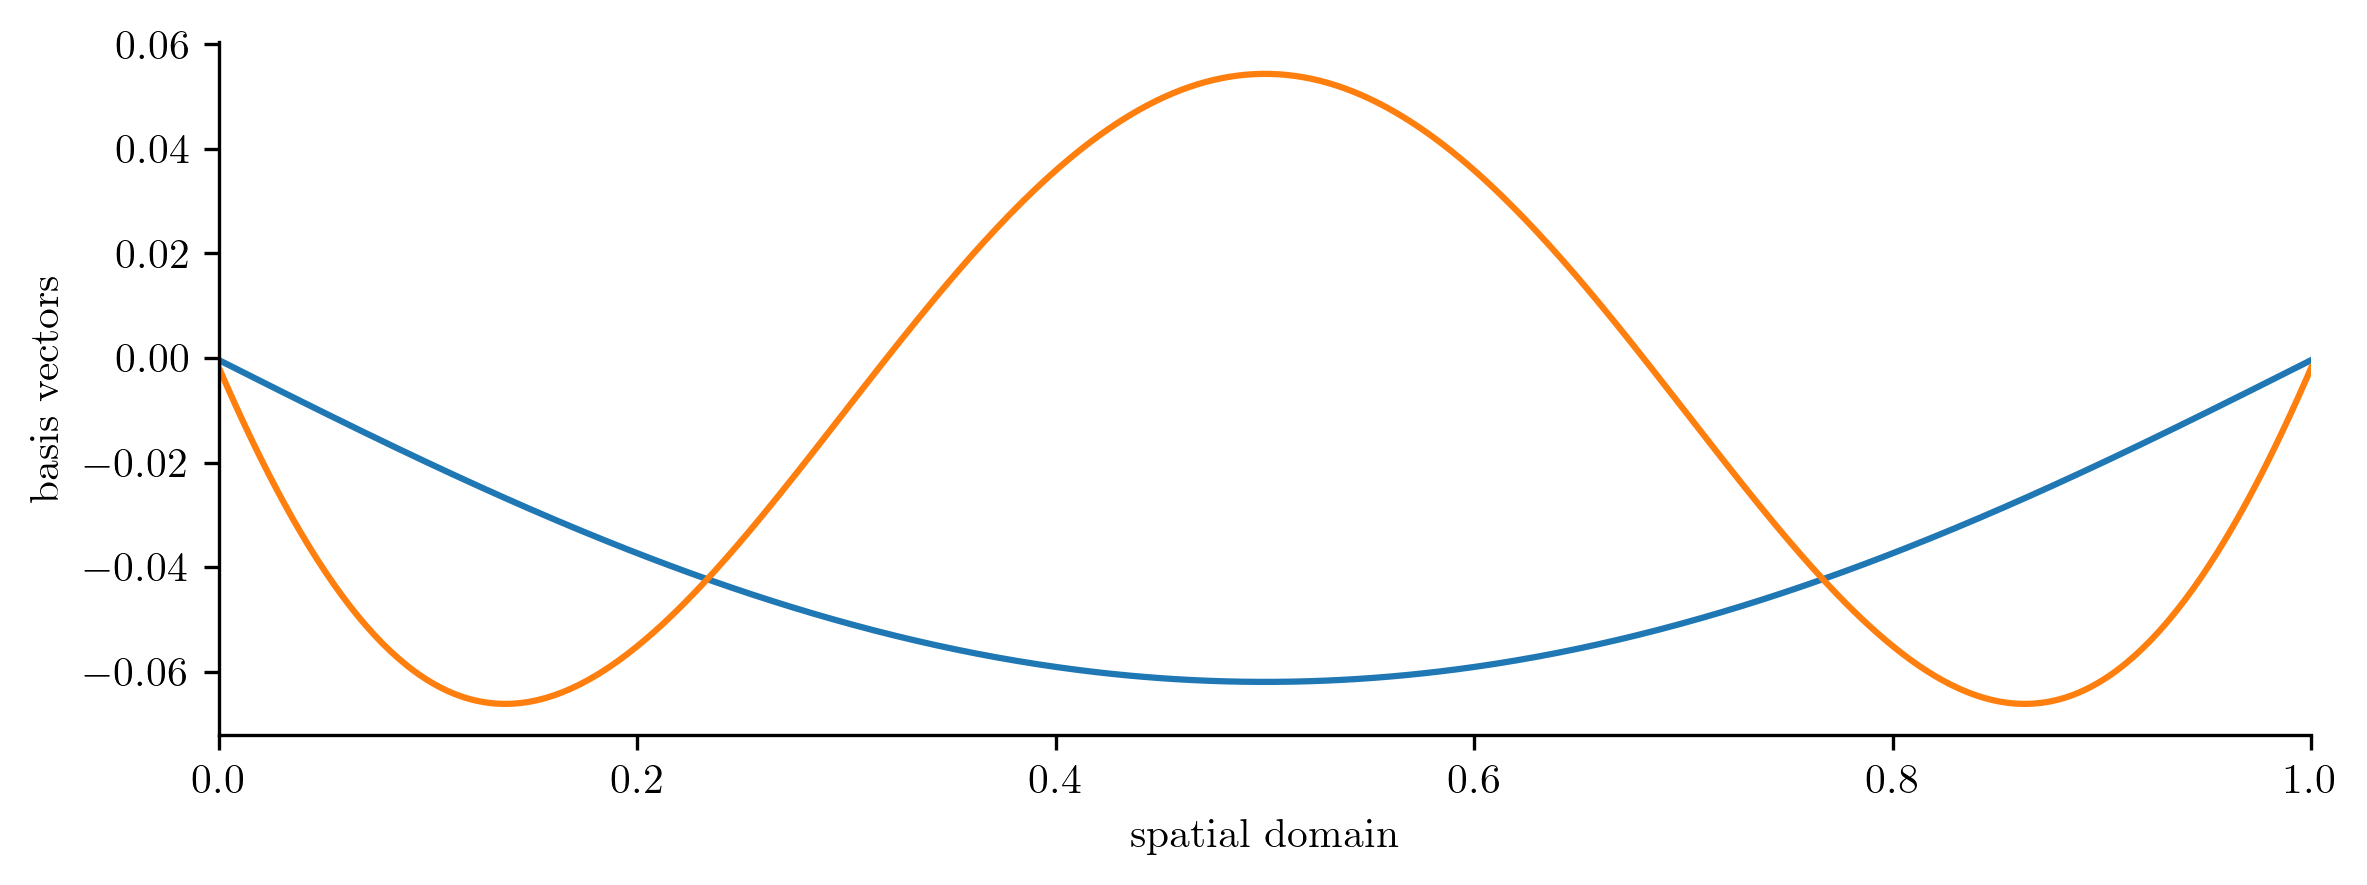

In [6]:
# Initialize a basis.
basis = opinf.basis.PODBasis(cumulative_energy=0.9999)

# Fit the basis (compute Vr) using the snapshot data.
basis.fit(Q)
print(basis)

# Visualize the basis vectors.
basis.plot1D(np.linspace(0, 1, Q.shape[0]))
plt.show()

Solutions of our eventual ROM are restricted to linear combinations of these two basis vectors.

After the basis is initialized and calibrated, we can use it to compress the state snapshots to an $r$-dimensional representation.
In this case, we have $\qhat_j = \Vr\trp\q_j \in \RR^{r}$.
These $\qhat_j$ are data for the ROM state $\qhat(t)$ at time $t_j$.

In [7]:
# Compress the state snapshots to the reduced space defined by the basis.
Q_ = basis.compress(Q)

print(f"{Q.shape=}, {Q_.shape=}")

Q.shape=(512, 401), Q_.shape=(2, 401)


To see how well the state can be represented by a given basis matrix, it is helpful to examine the _projection_ of the state snapshots.
For linear state approximations like POD, the projection of $\q\in\RR^n$ is the vector $\Vr\Vr\trp\q\in\RR^n$.

In [8]:
basis.projection_error(Q)

np.float64(0.0010076329248241494)

### Time Derivative Estimation

In addition to the compressed state snapshots $\qhat_0,\ldots,\qhat_{k-1}$, OpInf for time-continuous (ODE) models requires data for the time derivatives of the state snapshots, denoted

$$
\begin{aligned}
    \dot{\qhat}_j
    = \ddt\qhat(t)\big|_{t=t_j}
    \in\RR^{r}.
\end{aligned}
$$

There are two ways to get such data.

1. If time derivatives of the original state snapshots are available, they can be compressed to the reduced state space.
2. Otherwise, the time derivatives may be estimated from the compressed states.

The {mod}`opinf.ddt` module defines tools for estimating time derivatives from state data.

Recall that the FOM in this problem {eq}`eq_basics_fom` is given by $\ddt\q(t) = \A\q(t)$.
In this case we have $\A$, so we can compute $\dot{\q}_j = \A\q_j$, then set $\dot{\qhat}_j = \Vr\trp\dot{\q}_j$.
Below, we should how this approach compares with using tools from {mod}`opinf.ddt`.
Since the data $\q_0,\ldots,\q_{k-1}$ are defined on a uniform time grid, we use {class}`opinf.ddt.UniformFiniteDifferencer`.

In [9]:
# Estimate time derivatives using 6th-order finite differences.
ddt_estimator = opinf.ddt.UniformFiniteDifferencer(t, "ord6")
Qdot_ = ddt_estimator.estimate(Q_)[1]

print(Qdot_.shape)

(2, 401)


### Specifying the Model Operators

We now have low-dimensional state and time derivative data.
To learn a ROM with OpInf, we must specify the structure of the ROM, which should be motivated by the structure of the FOM and the dimensionality reduction strategy.

The FOM {eq}`eq_basics_fom` is a linear system of ODEs,

$$
\begin{aligned}
    \ddt\q(t) = \A\q(t),
    \qquad
    \q(0) = \q_0.
\end{aligned}
$$

Substituting in the approximation $\q(t)\approx\Vr\qhat(t)$, we have

$$
\begin{aligned}
    \ddt\Vr\qhat(t) = \A\Vr\qhat(t),
    \qquad
    \Vr\qhat(0) = \q_0.
\end{aligned}
$$

Next, left multiply by $\Vr\trp$ and use the fact that $\Vr\trp\Vr = \I$ to get the following:

$$
\begin{aligned}
    \ddt\qhat(t) = \tilde{\A}\qhat(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$ (eq_basics_intrusiverom)

where $\tilde{\A} = \Vr\trp\A\Vr \in \RR^{r\times r}$.
The system {eq}`eq_basics_intrusiverom` is called the _intrusive Galerkin ROM_ corresponding to the FOM and the choice of basis matrix $\Vr$.
The intrusive ROM can only be constructed if $\A$ is known; with OpInf, we aim to construct a reduced system with the same linear structure as the intrusive ROM, but without using $\A$ explicitly:

$$
\begin{aligned}
    \ddt\qhat(t) = \Ahat\qhat(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$

for some $\Ahat\in\RR^{r\times r}$ inferred from the training data.
We specify this linear structure by initializing an {class}`opinf.models.ContinuousModel` with the string `"A"`.


In [10]:
model = opinf.models.ContinuousModel("A")
print(model)

ContinuousModel
  structure: dq / dt = Aq(t)
  state_dimension: None
  input_dimension: 0
  operators:
    LinearOperator
      state_dimension: None
      entries.shape:   None
  solver: PlainSolver (not trained)
    solver: scipy.linalg.lstsq(cond=None, lapack_driver=None)


:::{admonition} Model Constructor Shortcut
:class: tip

The `"A"` argument in the constructor is a shortcut for a slightly longer statement:

```python
>>> model = opinf.models.ContinuousModel([opinf.operators.LinearOperator()])
```

The {class}`opinf.operators.LinearOperator` class represents the $r \times r$ matrix $\Ahat$, whose entries will be calibrated via regression.
See {mod}`opinf.operators` for the kinds of terms that OpInf ROMs can contain.
:::

### Calibrating Model Operators

Our task now is to learn the entries of $\Ahat$ using the compressed state snapshots $\qhat_0,\ldots,\qhat_{k-1}$ and the corresponding time derivatives $\dot{\qhat}_0,\ldots,\dot{\qhat}_{k-1}$.
OpInf does this through minimizing the residual of the model equation with respect to the data:

$$
\begin{aligned}
    \min_{\Ahat\in\RR^{r\times r}}
    \sum_{j=0}^{k-1}\left\|
        \Ahat\qhat_{j} - \dot{\qhat}_{j}
    \right\|_{2}^2
    + \mathcal{R}(\Ahat),
\end{aligned}
$$ (eq_basics_opinf)

where $\mathcal{R}(\Ahat)$ is a regularization term (more on this later).

The {mod}`opinf.lstsq` module defines tools for solving this problem (or variations on it).
By default, the regression is solved without regularization, i.e., $\mathcal{R}(\Ahat) = 0$.
The following code compares the OpInf ROM matrix $\Ahat$ to the intrusive ROM matrix $\tilde{\A} = \Vr\trp\A\Vr$.

In [11]:
model.fit(states=Q_, ddts=Qdot_)
print(model)

ContinuousModel
  structure: dq / dt = Aq(t)
  state_dimension: 2
  input_dimension: 0
  operators:
    LinearOperator
      state_dimension: 2
      entries.shape:   (2, 2)
  solver: PlainSolver
    data_matrix:     (401, 2)
      condition number: 9.0979e+01
    lhs_matrix:      (2, 401)
    solve().shape:   (2, 2)
    solver: scipy.linalg.lstsq(cond=None, lapack_driver=None)


### Regularization: Stabilizing the Inference Problem


Ill-conditioning in the data, errors in the estimation of the time derivatives, or overfitting to the data can result in an $\Ahat$ that defines an inaccurate or even unstable ROM.
Introducing a regularization term promotes solutions that respect both the training data and the physics of the problem.
One common option is [Tikhonov regularization](https://en.wikipedia.org/wiki/Tikhonov_regularization), which sets $\mathcal{R}(\Ahat) = \|\lambda\Ahat\|_{F}^{2}$ to penalize the entries of the learned operators.


In [12]:
# Define a solver for the Tikhonov-regularized least-squares problem.
model = opinf.models.ContinuousModel(
    "A",
    solver=opinf.lstsq.L2Solver(regularizer=1e-2),
)

# Construct the OpInf ROM through regularized least squares.
model.fit(states=Q_, ddts=Qdot_)
A_opinf = model.operators[0].entries

With inexact time derivatives or regularization, OpInf differs slightly from the intrusive operator $\tilde{\A}$.
However, we will see that in this example the ROM produced by OpInf is highly accurate.
In fact, it is sometimes the case that OpInf outperforms intrusive Galerkin projection.

:::{admonition} Regularization Matters
:class: important

Regularization is important in all but the simplest OpInf problems.
If OpInf produces an unstable ROM, try different values for the `regularizer`.
See {cite}`mcquarrie2021combustion` for an example of a principled choice of regularization for a combustion problem.
:::

### Solving the Reduced-order Model

Once the model is calibrated, we may solve the ROM with {meth}`opinf.models.ContinuousModel.predict`, which wraps {func}`scipy.integrate.solve_ivp()`. This method takes an initial condition for the model $\qhat_0 = \Vr\trp\q_0$, the time domain over which to record the solution, and any additional arguments for the integrator.

In [13]:
q0_ = basis.compress(q0)  # Compress the initial conditions.

model = opinf.models.ContinuousModel(
    "A",
    solver=opinf.lstsq.L2Solver(regularizer=1e-8),
).fit(Q_, Qdot_)

Q_ROM_ = model.predict(q0_, t, method="BDF")

print(f"{Q_ROM_.shape=}")

Q_ROM_.shape=(2, 401)


The solution is still in the low-dimensional state space; it can be mapped to the original state space by applying $\Vr$.

In [14]:
Q_ROM = basis.decompress(Q_ROM_)

print(f"{Q_ROM.shape=}")

Q_ROM.shape=(512, 401)


:::{admonition} Custom ODE Solvers
:class: tip

{meth}`opinf.models.ContinuousModel.predict` is convenient, but {func}`scipy.integrate.solve_ivp()` implements a limited repertoire of time integration schemes.
However, the ROM can be simulated by any ODE solver scheme by extracting the inferred operator $\Ahat$. 
If `timestepper(A, q0)` were a solver for systems of the form $\ddt\qhat = \Ahat\qhat(t),\ \qhat(0) = \qhat_0$, we could simulate the ROM with the following code.

```python
q0_ = basis.compress(q0)                        # Compress the initial conditions.
Q_ROM_ = timestepper(model.A_.entries, q0_)     # Solve the ROM in the reduced space.
Q_ROM = basis.decompress(Q_ROM_)                # Decompress the ROM solutions.
```

More generally, the method {meth}`opinf.models.ContinuousModel.rhs` represents the right-hand side of the model, the $\hat{\mathbf{f}}$ of $\ddt\qhat(t) = \hat{\mathbf{f}}(t, \qhat(t))$.
General-purpose integrators can therefore be applied to the function {meth}`opinf.models.ContinuousModel.rhs`.
:::

### The ROM Class

Up to this point, we have done the following steps using several package submodules.

1. {mod}`opinf.basis`: Data compression.
2. {mod}`opinf.ddt`: Time derivative estimation.
3. {mod}`opinf.models`: Specify and [calibrate](opinf.lstsq) model [operators](opinf.operators), then integrate the reduced system.

The [`opinf.ROM`](opinf.roms.ROM) class wraps these steps for convenience.
Its constructor takes a initialized basis, time derivative estimator, and model objects.
Then, [`fit()`](opinf.roms.ROM.fit) calibrates the basis, compresses the state data, estimates the time derivatives, and calibrates the model.
Use [`predict()`](opinf.roms.ROM.predict) to compress initial conditions, solve the model, and express the solutions in the original state space.

In [15]:
rom = opinf.ROM(
    basis=opinf.basis.PODBasis(cumulative_energy=0.9999),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel(
        operators="A",
        solver=opinf.lstsq.L2Solver(regularizer=1e-8),
    ),
)

print(rom)

ROM
  basis: PODBasis
    full_state_dimension:    None
    reduced_state_dimension: None
    SVD solver: scipy.linalg.svd()
  ddt_estimator: UniformFiniteDifferencer
    time_domain: 401 entries in [0.0, 1.0]
    dt:          2.5000e-03
    scheme:      ord6()
  model: ContinuousModel
    structure: dq / dt = Aq(t)
    state_dimension: None
    input_dimension: 0
    operators:
      LinearOperator
        state_dimension: None
        entries.shape:   None
    solver: L2Solver (not trained)
      regularizer:     1.0000e-08
      SVD solver:      scipy.linalg.svd(full_matrices=False, lapack_driver='gesdd')


In [16]:
rom.fit(Q)

print(rom)

ROM
  basis: PODBasis
    full_state_dimension:    512
    reduced_state_dimension: 2
    cumulative energy: 99.999898%
    residual energy:   1.0153e-06
    401 basis vectors available
    SVD solver: scipy.linalg.svd()
  ddt_estimator: UniformFiniteDifferencer
    time_domain: 401 entries in [0.0, 1.0]
    dt:          2.5000e-03
    scheme:      ord6()
  model: ContinuousModel
    structure: dq / dt = Aq(t)
    state_dimension: 2
    input_dimension: 0
    operators:
      LinearOperator
        state_dimension: 2
        entries.shape:   (2, 2)
    solver: L2Solver
      data_matrix:     (401, 2)
        condition number: 9.0979e+01
      lhs_matrix:      (2, 401)
      solve().shape:   (2, 2)
      regularizer:     1.0000e-08
      SVD solver:      scipy.linalg.svd(full_matrices=False, lapack_driver='gesdd')


In [17]:
Q_ROM_2 = rom.predict(q0, t, method="BDF")

np.all(Q_ROM_2 == Q_ROM)

np.True_

### Evaluate ROM Performance

The quality or usefulness of a ROM depends on its accuracy and its computational efficiency.

#### ROM Accuracy

To get a sense of how well the ROM approximates the FOM, we begin by visualizing the simulation output `Q_ROM`.
It should look similar to the plot of the snapshot data `Q`.

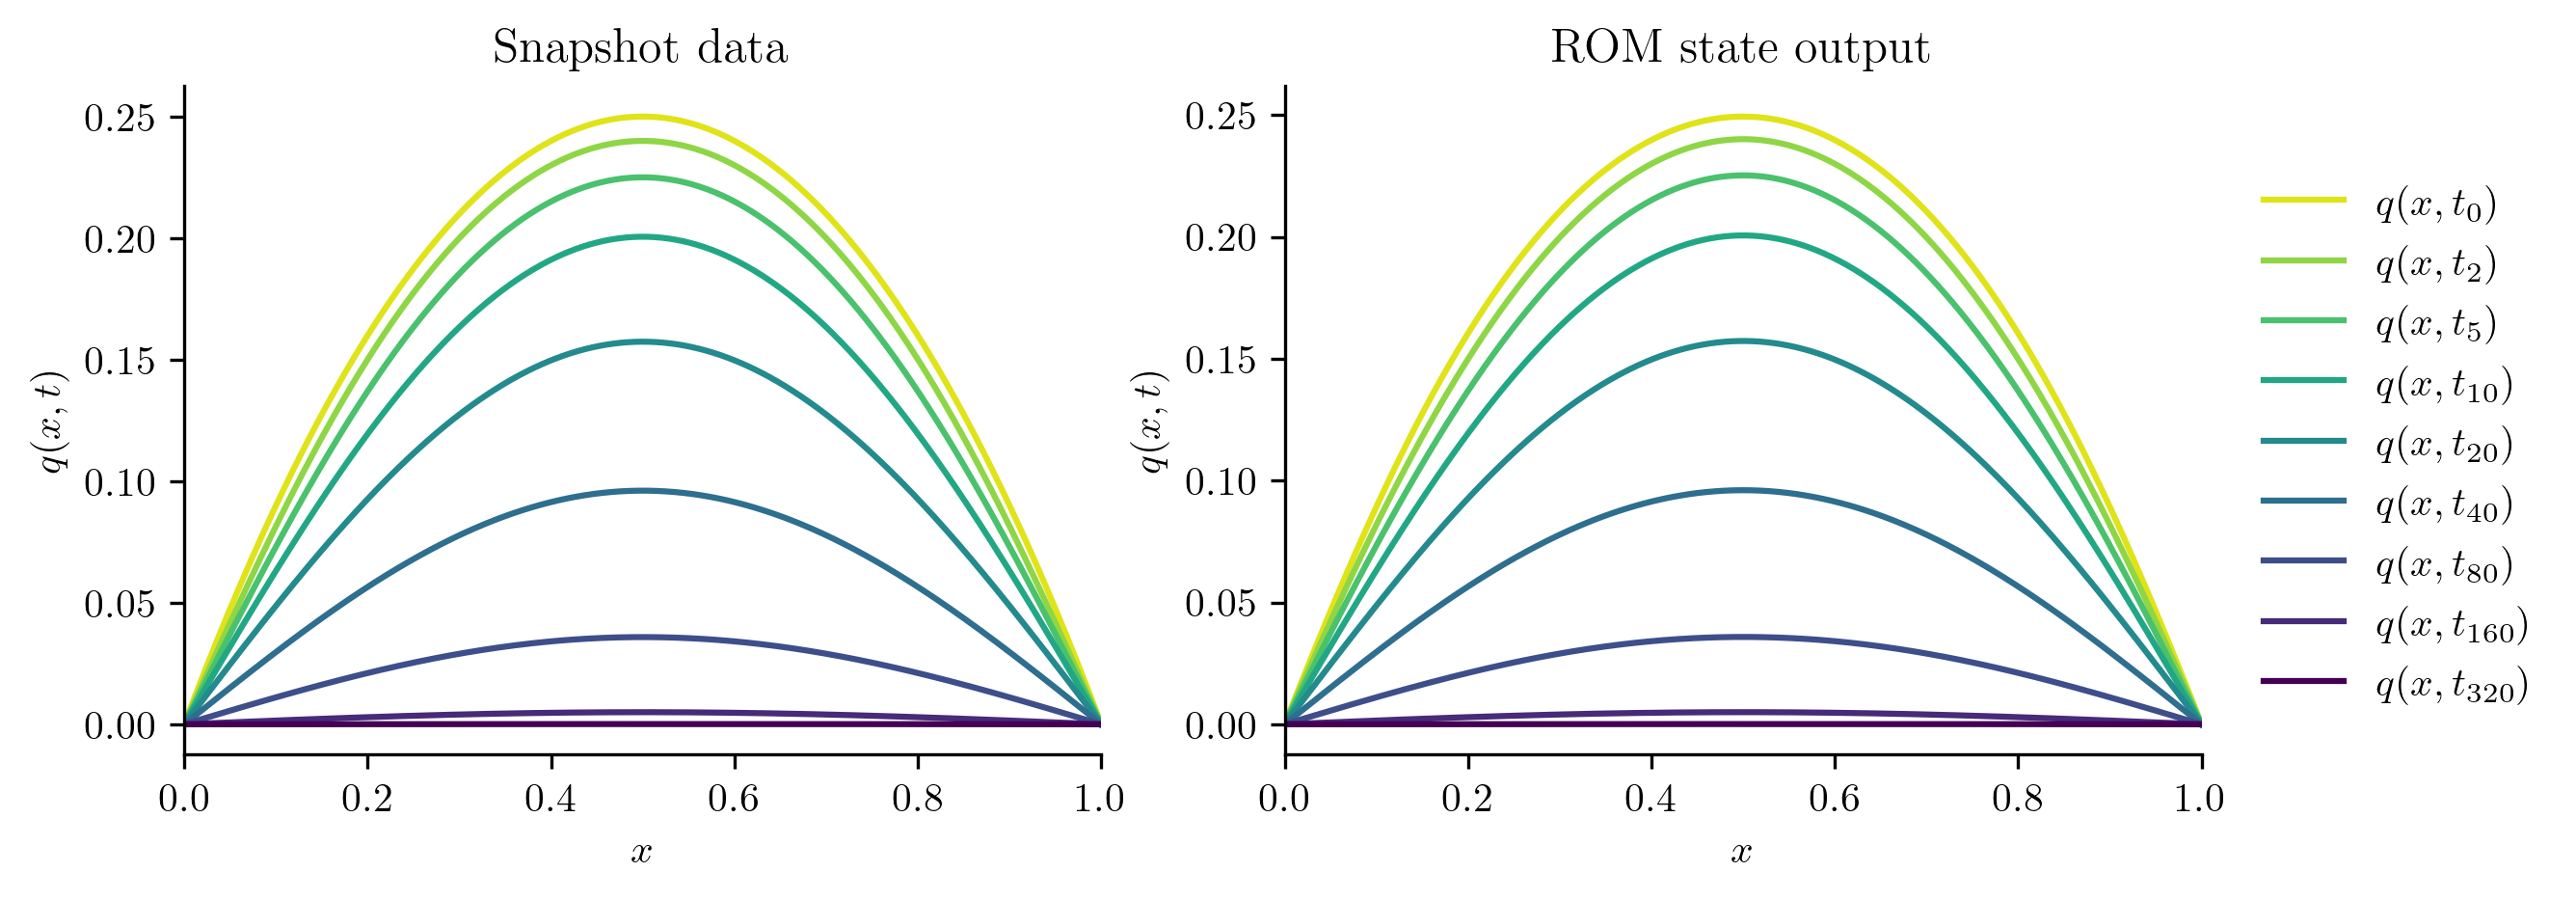

In [18]:
fig, [ax1, ax2] = plt.subplots(1, 2)
plot_heat_data(Q, "Snapshot data", ax1)
plot_heat_data(Q_ROM, "ROM state output", ax2)
ax1.legend([])
plt.show()

For more detail, we evaluate the $\ell^2$ error of the ROM output, comparing it to the snapshot set via {func}`opinf.post.lp_error`.
This calculates the absolute and relative error as a function of time,

$$
\begin{aligned}
    \text{err}_\text{absolute}(t)
    &= \|\q(t) - \q_{\text{ROM}}(t)\|_{2},
    \\ ~ \\
    \text{err}_\text{relative}(t)
    &= \frac{\|\q(t) - \q_{\text{ROM}}(t)\|_{2}}{\|\q(t)\|_{2}}.
\end{aligned}
$$


:::{admonition} Normalized Absolute Error
:class: tip

In this problem, $\q(t)\to\0$ as $t$ increases, so a relative error may not be appropriate since $\|\q(t)\|_{2}$ appears in the denominator.
In situations like this, consider using the _normalized absolute error_ by replacing the denominator with $\max_{\tau\in[t_0,t_f]}\|\q(t)\|.$
Set `normalize=True` in {func}`opinf.post.lp_error()` to use this error measure instead of the relative error.
:::

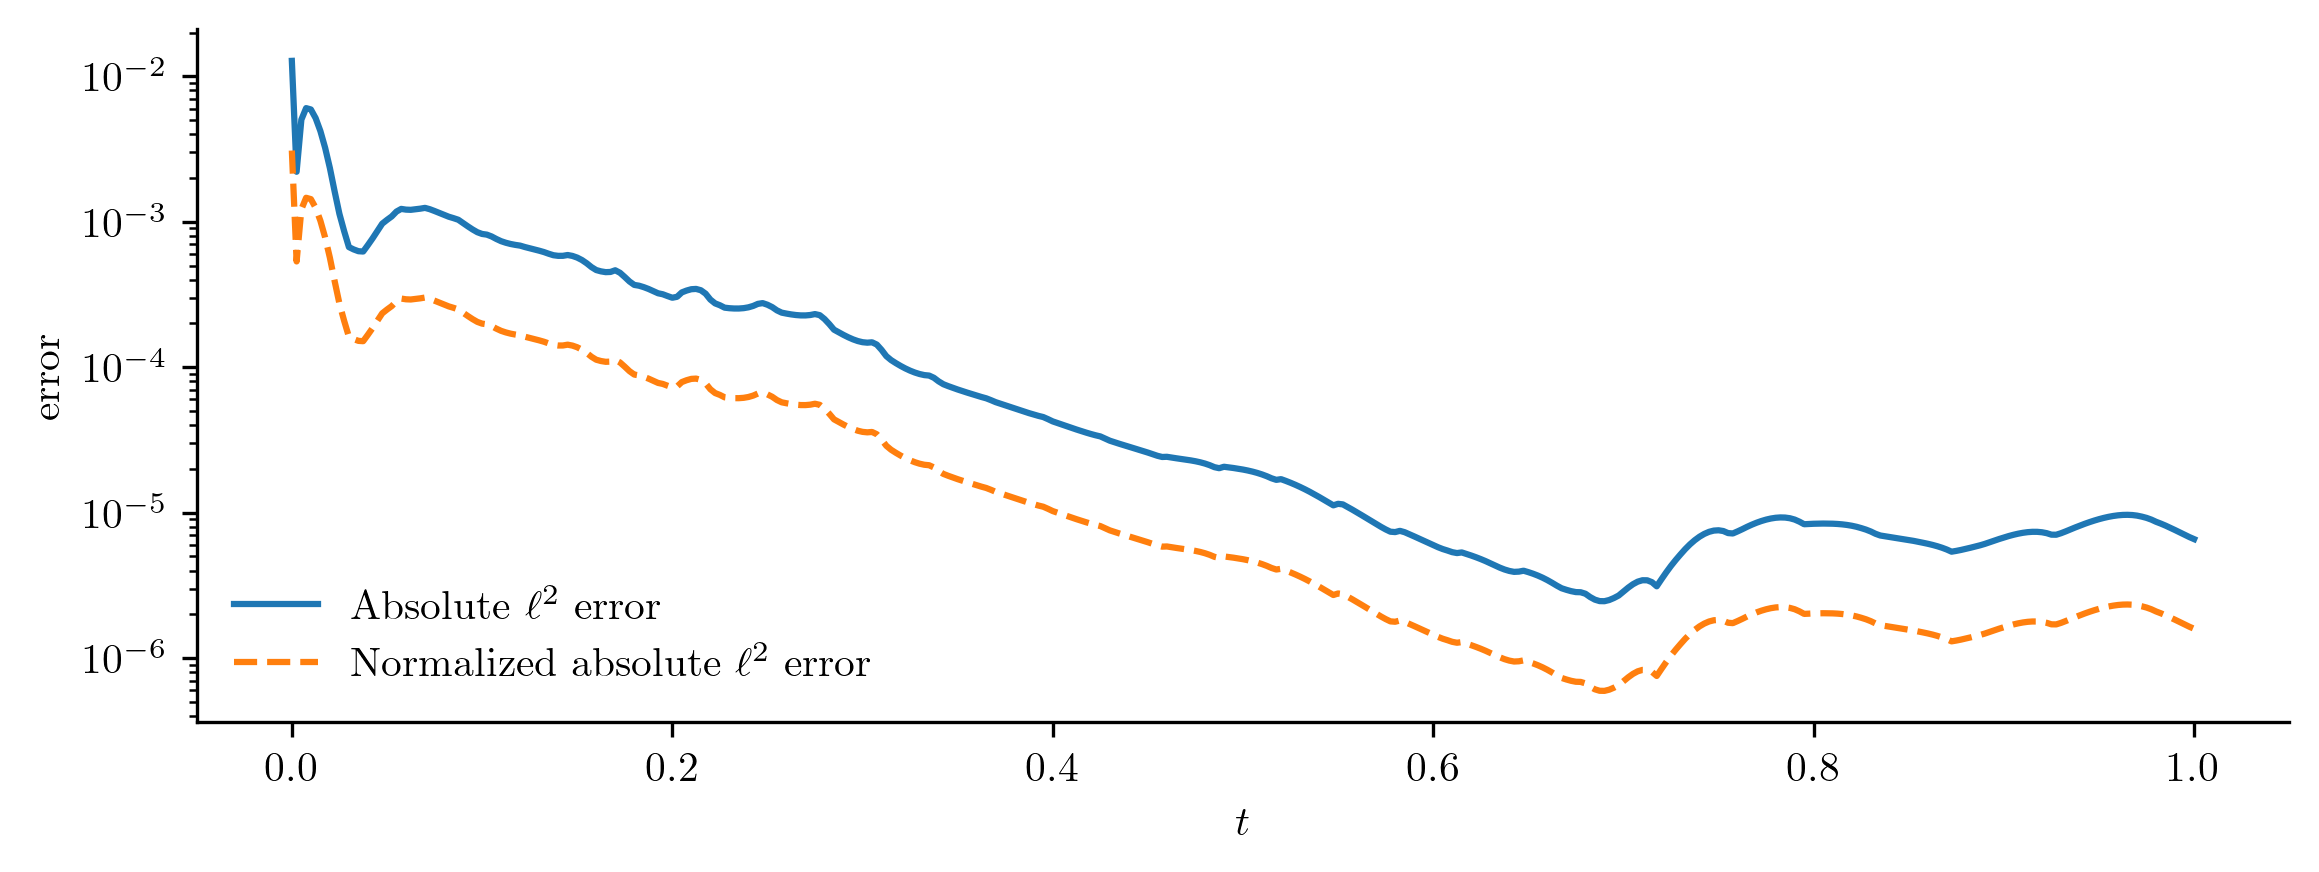

In [19]:
abs_l2err, norm_l2err = opinf.post.lp_error(Q, Q_ROM, normalize=True)
fig, ax = plt.subplots(1, 1)
ax.semilogy(t, abs_l2err, "-", label=r"Absolute $\ell^2$ error")
ax.semilogy(t, norm_l2err, "--", label=r"Normalized absolute $\ell^2$ error")
ax.set_xlabel(r"$t$")
ax.set_ylabel("error")
ax.legend(loc="lower left")
plt.show()

In this simple example, the error decreases with time (as solutions get quickly pushed to zero), but this is not the kind of error behavior that should be expected when modeling more complicated phenomena.

We can also get a scalar error measurement by calculating the relative Frobenius norm error with {func}`opinf.post.frobenius_error`.

In [20]:
abs_froerr, rel_froerr = opinf.post.frobenius_error(Q, Q_ROM)
print(f"Relative Frobenius-norm error: {rel_froerr:%}")

Relative Frobenius-norm error: 0.102789%


In other words, the ROM simulation is within about 0.1% of the snapshot data.
Note that this value is very close to the projection error that we calculated earlier.

#### ROM Computational Speedup

When a FOM is available, a ROM is only useful if it can be solved much faster than the FOM.
The solution speed can be quickly checked using {class}`opinf.utils.TimedBlock`.

In [21]:
def full_order_solve(initial_condition, time_domain):
    """Solve the full-order model with SciPy."""
    dx = x[1] - x[0]
    diags = np.array([1, -2, 1]) / (dx**2)
    A = scipy.sparse.diags(diags, [-1, 0, 1], (Q.shape[0], Q.shape[0]))
    return scipy.integrate.solve_ivp(
        fun=lambda t, q: A @ q,
        t_span=[time_domain[0], time_domain[-1]],
        y0=initial_condition,
        t_eval=time_domain,
        method="BDF",
    ).y

In [22]:
with opinf.utils.TimedBlock("Full-order solve"):
    full_order_solve(q0, t)

Full-order solve...done in 0.59 s.


In [23]:
with opinf.utils.TimedBlock("Reduced-order solve"):
    rom.predict(q0, t, method="BDF")

Reduced-order solve...done in 0.03 s.


More precise measurements can be take by aliasing the {class}`opinf.utils.TimedBlock` and accessing the `elapsed` attribute.
Below, we solve each model several times to get an average time.

In [24]:
n_trials = 10

with opinf.utils.TimedBlock(f"{n_trials} FOM solves") as fomtime:
    for _ in range(n_trials):
        full_order_solve(q0, t)

with opinf.utils.TimedBlock(f"{n_trials} ROM solves") as romtime:
    for _ in range(n_trials):
        rom.predict(q0, t, method="BDF")

print(f"Average FOM time: {fomtime.elapsed / n_trials :.6f} s")
print(f"Average ROM time: {romtime.elapsed / n_trials :.6f} s")
print(f"ROM speedup: {fomtime.elapsed / romtime.elapsed :.4f} times!")

10 FOM solves...done in 5.20 s.
10 ROM solves...done in 0.14 s.
Average FOM time: 0.520312 s
Average ROM time: 0.014063 s
ROM speedup: 37.0000 times!


In this example, the FOM is efficient because it takes advantage of the sparsity of $\A\in\RR^{n\times n}$.
Even so, the ROM achieves a modest speedup due to the smaller size of $\Ahat\in\RR^{r\times r}$.

## Prediction: New Initial Conditions

The ROM was trained using only data corresponding to the initial condition $q_0(x) = x(1 - x).$ We'll now test the ROM on the following new initial conditions and compare the results to the corresponding FOM solution:

$$
\begin{aligned}
    q_0(x) &= 10x (1 - x),
    &
    q_0(x) &= 5x^{2}(1 - x)^{2},
    \\
    q_0(x) &= 50x^{4}(1 - x)^{4},
    &
    q_0(x) &= \frac{1}{2}\sqrt{x(1 - x)},
    \\
    q_0(x) &= \frac{1}{4}\sqrt[4]{x(1 - x)},
    &
    q_0(x) &= \frac{1}{3}\sin(\pi x) + \tfrac{1}{5}\sin(5\pi x).
\end{aligned}
$$

Before we compute the ROM error, we also compute the _projection error_ of the new initial condition,

$$
\begin{aligned}
    \frac{||\q_{0} - \Vr \Vr\trp\q_{0}||_{2}}{||\q_{0}||_{2}}.
\end{aligned}
$$

If this projection error is large, then the new initial condition cannot be represented well within the range of $\Vr$. This will be apparent in the ROM solutions.

### First Attempt

In [25]:
def test_new_initial_condition(q0, rom, label=None):
    """Compare full-order model and reduced-order model solutions for a given
    initial condition.

    Parameters
    ----------
    q0 : (n,) ndarray
        Heat equation initial conditions q0(x) to be tested.
    rom : opinf.ROM
        Trained reduced-order model object.
    label : str
        Description of the initial condition being tested.
    """
    # Calculate the projection error of the new initial condition.
    rel_projerr = rom.basis.projection_error(q0, relative=True)

    # Solve the full-order model (FOM) and the reduced-order model (ROM).
    Q_FOM = full_order_solve(q0, t)
    Q_ROM = rom.predict(q0, t, method="BDF")

    # Plot the FOM and ROM solutions side by side.
    fig, [ax1, ax2] = plt.subplots(1, 2)
    plot_heat_data(Q_FOM, "Full-order model solution", ax1)
    plot_heat_data(Q_ROM, "Reduced-order model solution", ax2)
    ax1.legend([])
    if label:
        fig.suptitle(label, y=1)
    fig.tight_layout()

    # Calculate the ROM error in the Frobenius norm.
    abs_froerr, rel_froerr = opinf.post.frobenius_error(Q_FOM, Q_ROM)

    # Report results.
    plt.show()
    print(
        f"Relative projection error of initial condition: {rel_projerr:.2%}",
        f"Relative Frobenius-norm ROM error: {rel_froerr:.2%}",
        sep="\n",
    )
    return rel_projerr, rel_froerr

In [ ]:
q0_new = [
    10 * x * (1 - x),
    5 * x**2 * (1 - x) ** 2,
    50 * x**4 * (1 - x) ** 4,
    0.5 * np.sqrt(x * (1 - x)),
    0.25 * np.sqrt(np.sqrt(x * (1 - x))),
    np.sin(np.pi * x) / 3 + np.sin(5 * np.pi * x) / 5,
]

q0_titles = [
    r"$q_{0}(x) = 10 x (1 - x)$",
    r"$q_{0}(x) = 5 x^{2} (1 - x)^{2}$",
    r"$q_{0}(x) = 50 x^{4} (1 - x)^{4}$",
    r"$q_{0}(x) = \frac{1}{2}\sqrt{x (1 - x)}$",
    r"$q_{0}(x) = \frac{1}{4}\sqrt[4]{x (1 - x)}$",
    r"$q_{0}(x) = \frac{1}{3}\sin(\pi x) + \frac{1}{5}\sin(5\pi x)$",
]

results = {}
for i, [q00, title] in enumerate(zip(q0_new, q0_titles)):
    results[f"Experiment {i+1:d}"] = test_new_initial_condition(
        q00, rom, f"Experiment {i+1}: {title}"
    )

labels = [
    "Relative projection error of initial condition",
    "Relative Frobenius-norm ROM error",
]
pd.DataFrame(results, index=labels).T

### Second Attempt: a Better Basis

The ROM performs well for $q_{0}(x) = 10x(1 - x)$, which is unsurprising because this new initial condition is a scalar multiple of the initial condition used to generate the training data.
In other cases, the ROM is less successful because the new initial condition cannot be represented well in the span of the basis vectors.
For example:

In [ ]:
def plot_initial_condition_projection(base):
    """Plot initial conditions 4 and 5 and their projections with respect to
    the basis `base`.

    Parameters
    ----------
    base : opinf.basis.PODBasis
        Trained basis object.
    """
    fig, axes = plt.subplots(1, 2)
    for j, ax in zip([4, 5], axes):
        ax.plot(
            x,
            q0_new[j],
            label=r"True initial condition ($\mathbf{q}_{0}$)",
        )
        ax.plot(
            x,
            base.project(q0_new[j]),
            "--",
            label=r"Basis approximation of initial condition "
            r"($\mathbf{V}_{\!r}\mathbf{V}_{\!r}^{\mathsf{T}}\mathbf{q}_{0}$)",
        )
        ax.set_title(f"Experiment {j+1:d}")

    fig.tight_layout(rect=[0, 0.15, 1, 1])
    axes[0].legend(
        loc="lower center",
        fontsize="large",
        bbox_to_anchor=(0.5, -0.05),
        bbox_transform=fig.transFigure,
    )
    plt.show()

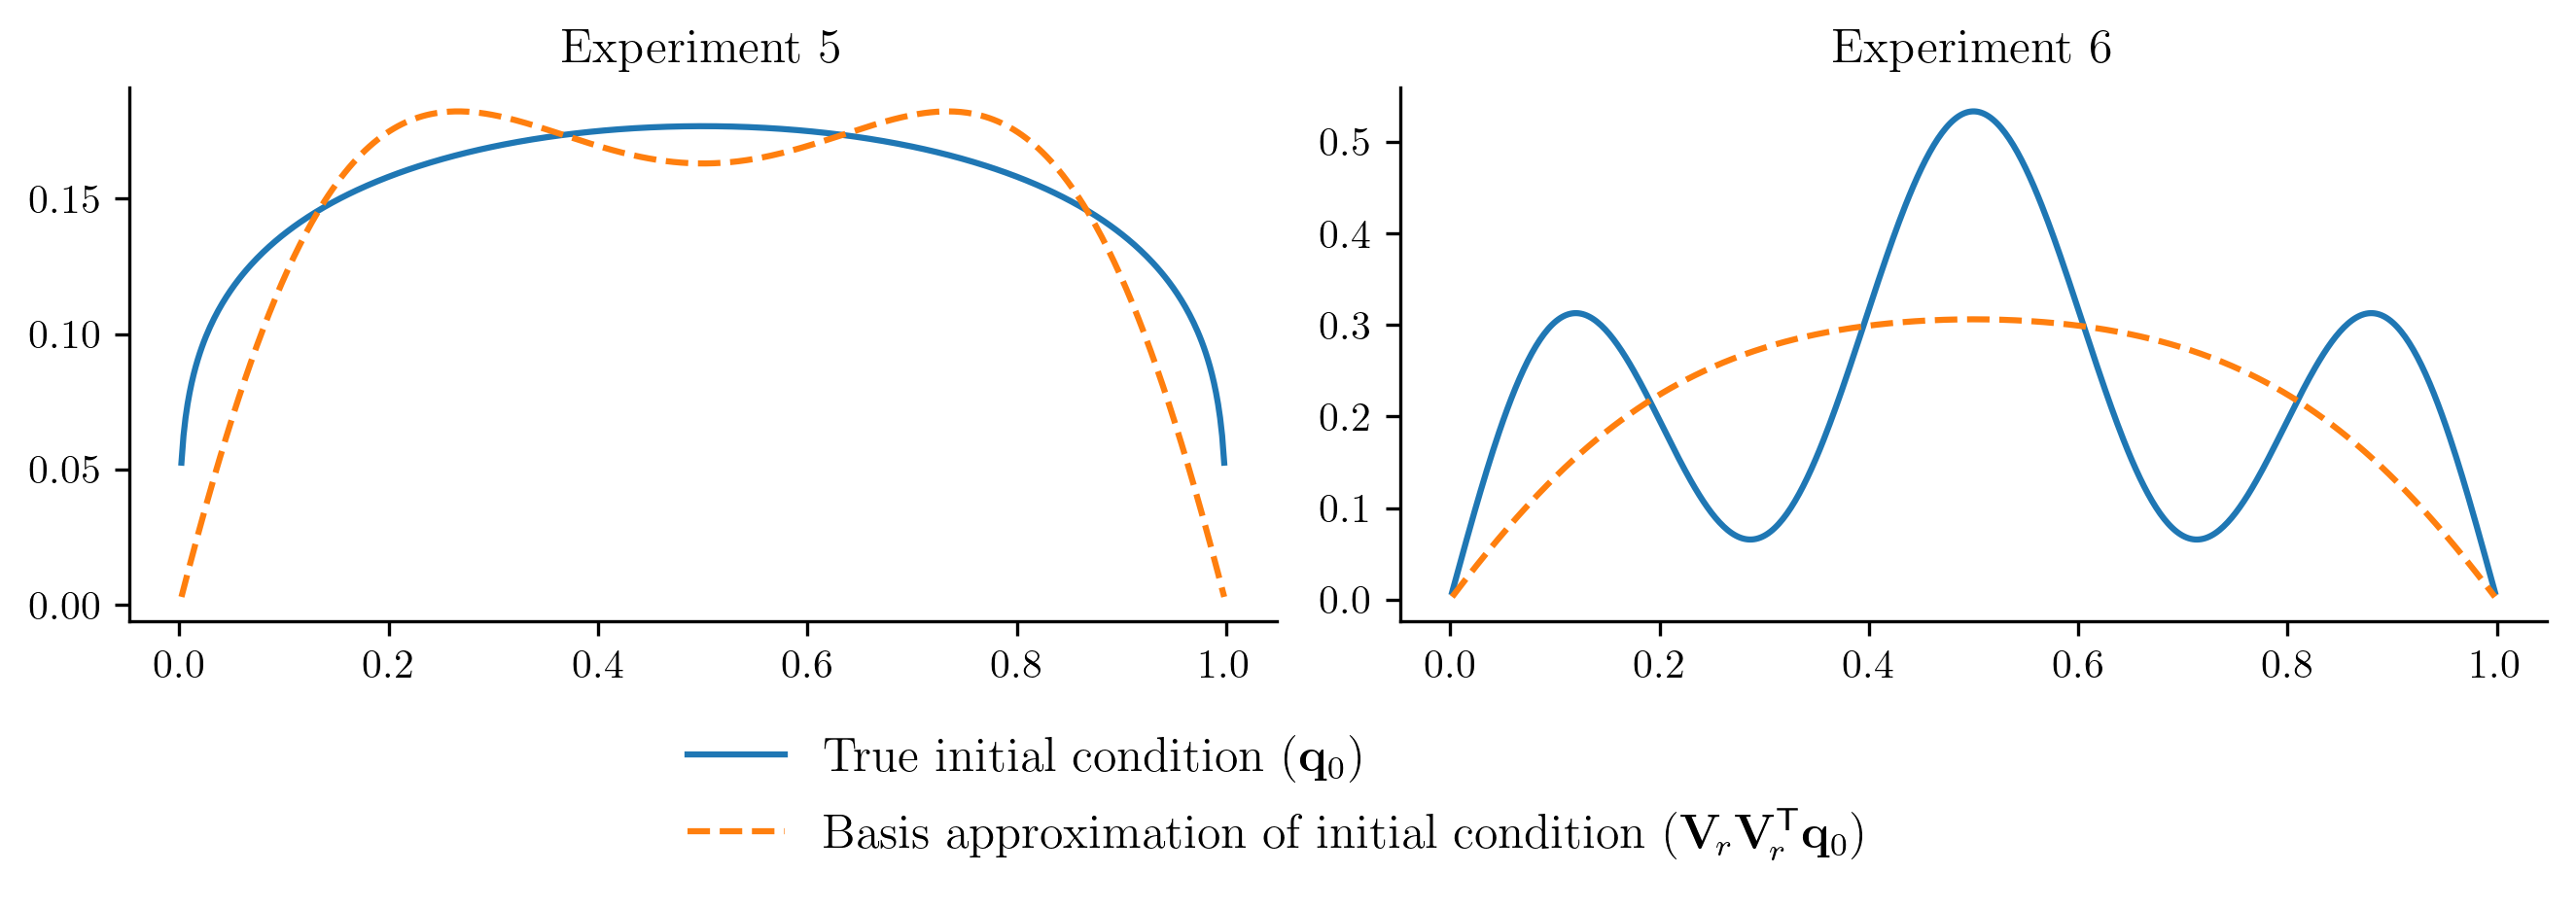

In [ ]:
plot_initial_condition_projection(basis)

To improve the ROM performace _without getting new data from the FOM_, we will enrich the basis by

1. Including the new initial conditions in the basis computation, and 
2. Using a few more basis vectors (we currently have $r = 2$, let's use $r = 5$).

PODBasis
  full_state_dimension:    512
  reduced_state_dimension: 5
  cumulative energy: 99.999994%
  residual energy:   6.1611e-08
  407 basis vectors available
  SVD solver: scipy.linalg.svd()


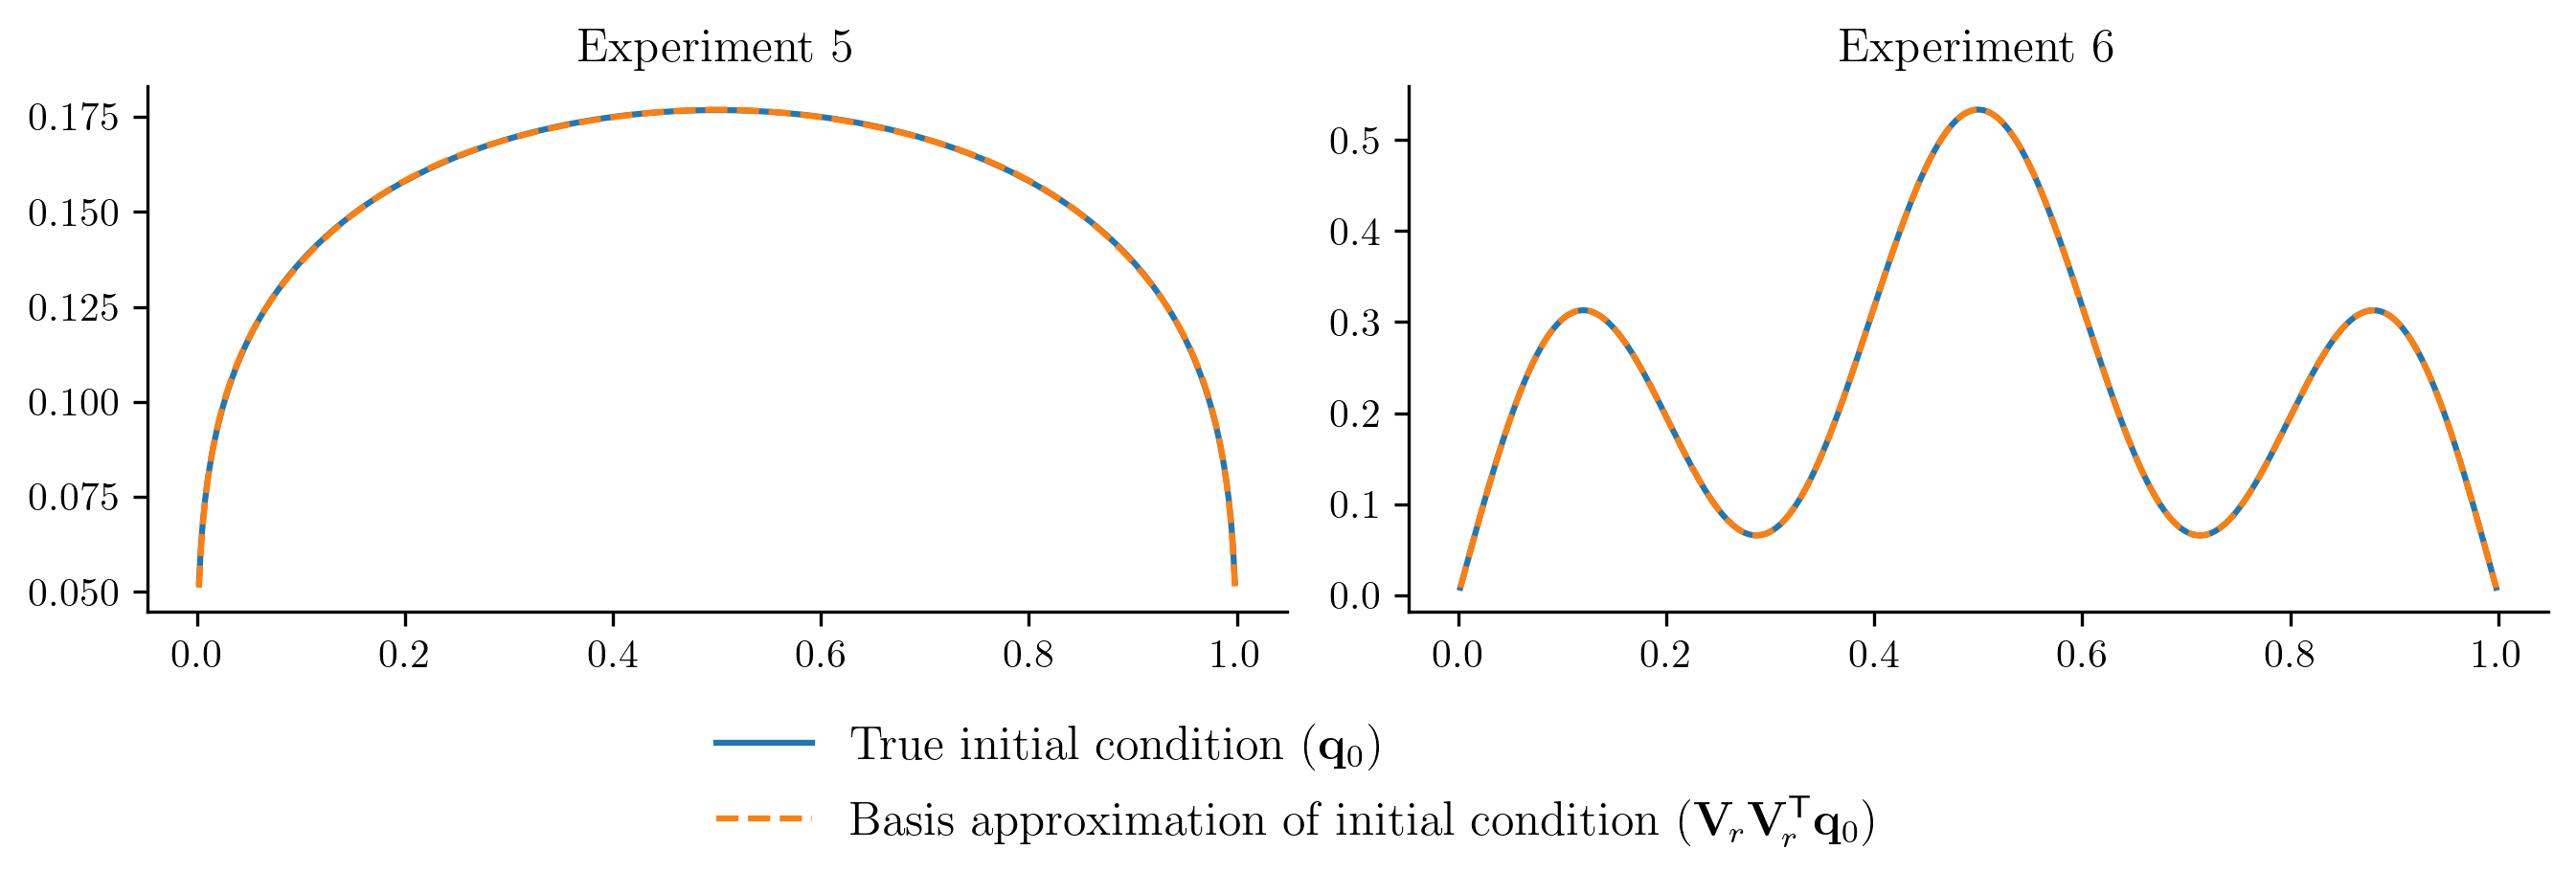

In [ ]:
# Include the new initial conditions in the basis training data.
Q_and_new_q0s = np.column_stack((Q, *q0_new))
newbasis = opinf.basis.PODBasis(num_vectors=5).fit(Q_and_new_q0s)
print(newbasis)

# Plot the projection of the initial conditions in the new basis
plot_initial_condition_projection(newbasis)

In [ ]:
# Initialize a ROM with the new basis.
rom = opinf.ROM(
    basis=newbasis,
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel(
        operators="A",
        solver=opinf.lstsq.L2Solver(regularizer=1e-8),
    ),
)

# Use the same training data as before, but do not reset the basis.
_ = rom.fit(Q, fit_basis=False)

print(rom)

ROM
  basis: PODBasis
    full_state_dimension:    512
    reduced_state_dimension: 5
    cumulative energy: 99.999994%
    residual energy:   6.1611e-08
    407 basis vectors available
    SVD solver: scipy.linalg.svd()
  ddt_estimator: UniformFiniteDifferencer
    time_domain: 401 entries in [0.0, 1.0]
    dt:          2.5000e-03
    scheme:      ord6()
  model: ContinuousModel
    structure: dq / dt = Aq(t)
    state_dimension: 5
    input_dimension: 0
    operators:
      LinearOperator
        state_dimension: 5
        entries.shape:   (5, 5)
    solver: L2Solver
      data_matrix:     (401, 5)
        condition number: 7.2022e+04
      lhs_matrix:      (5, 401)
      solve().shape:   (5, 5)
      regularizer:     1.0000e-08
      SVD solver:      scipy.linalg.svd(full_matrices=False, lapack_driver='gesdd')


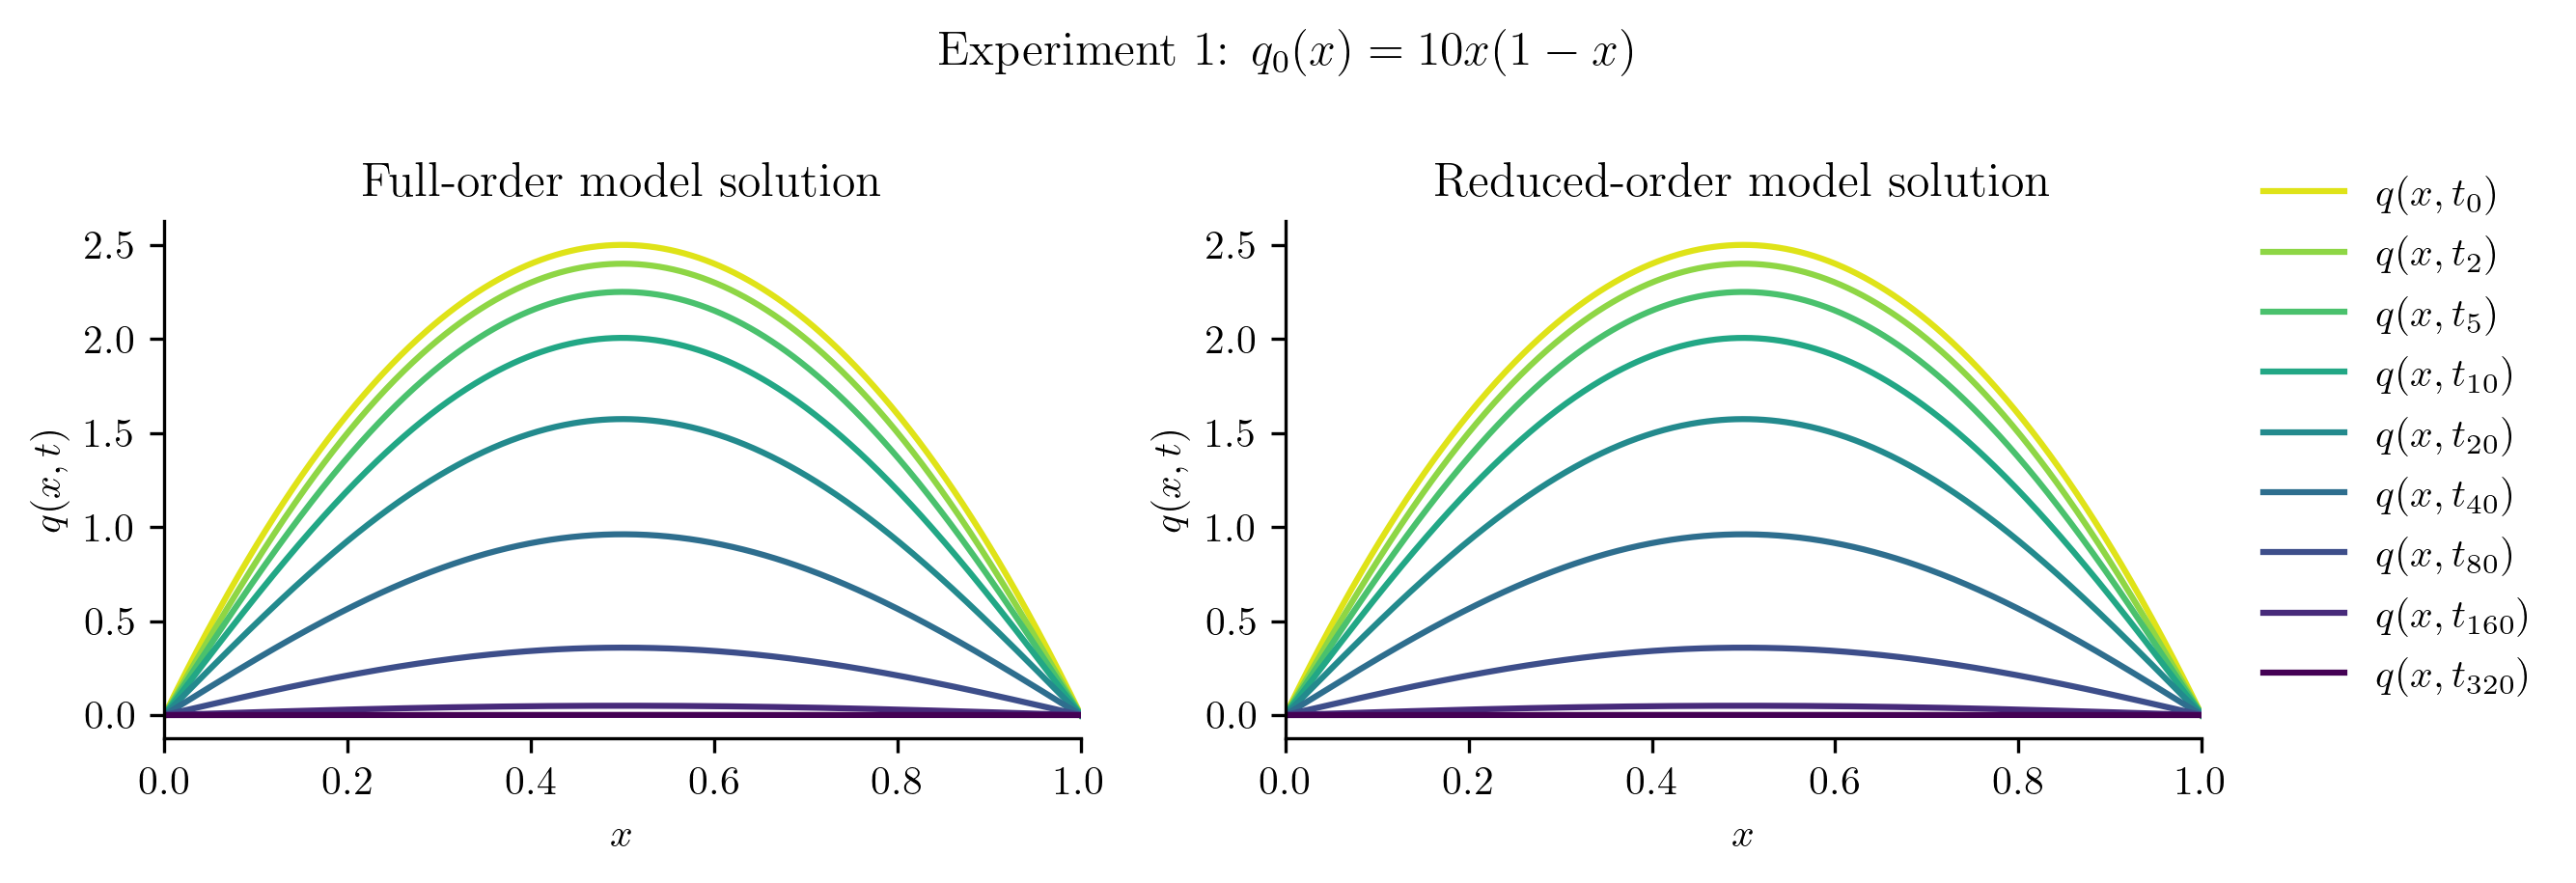

Relative projection error of initial condition: 0.01%
Relative Frobenius-norm ROM error: 0.02%


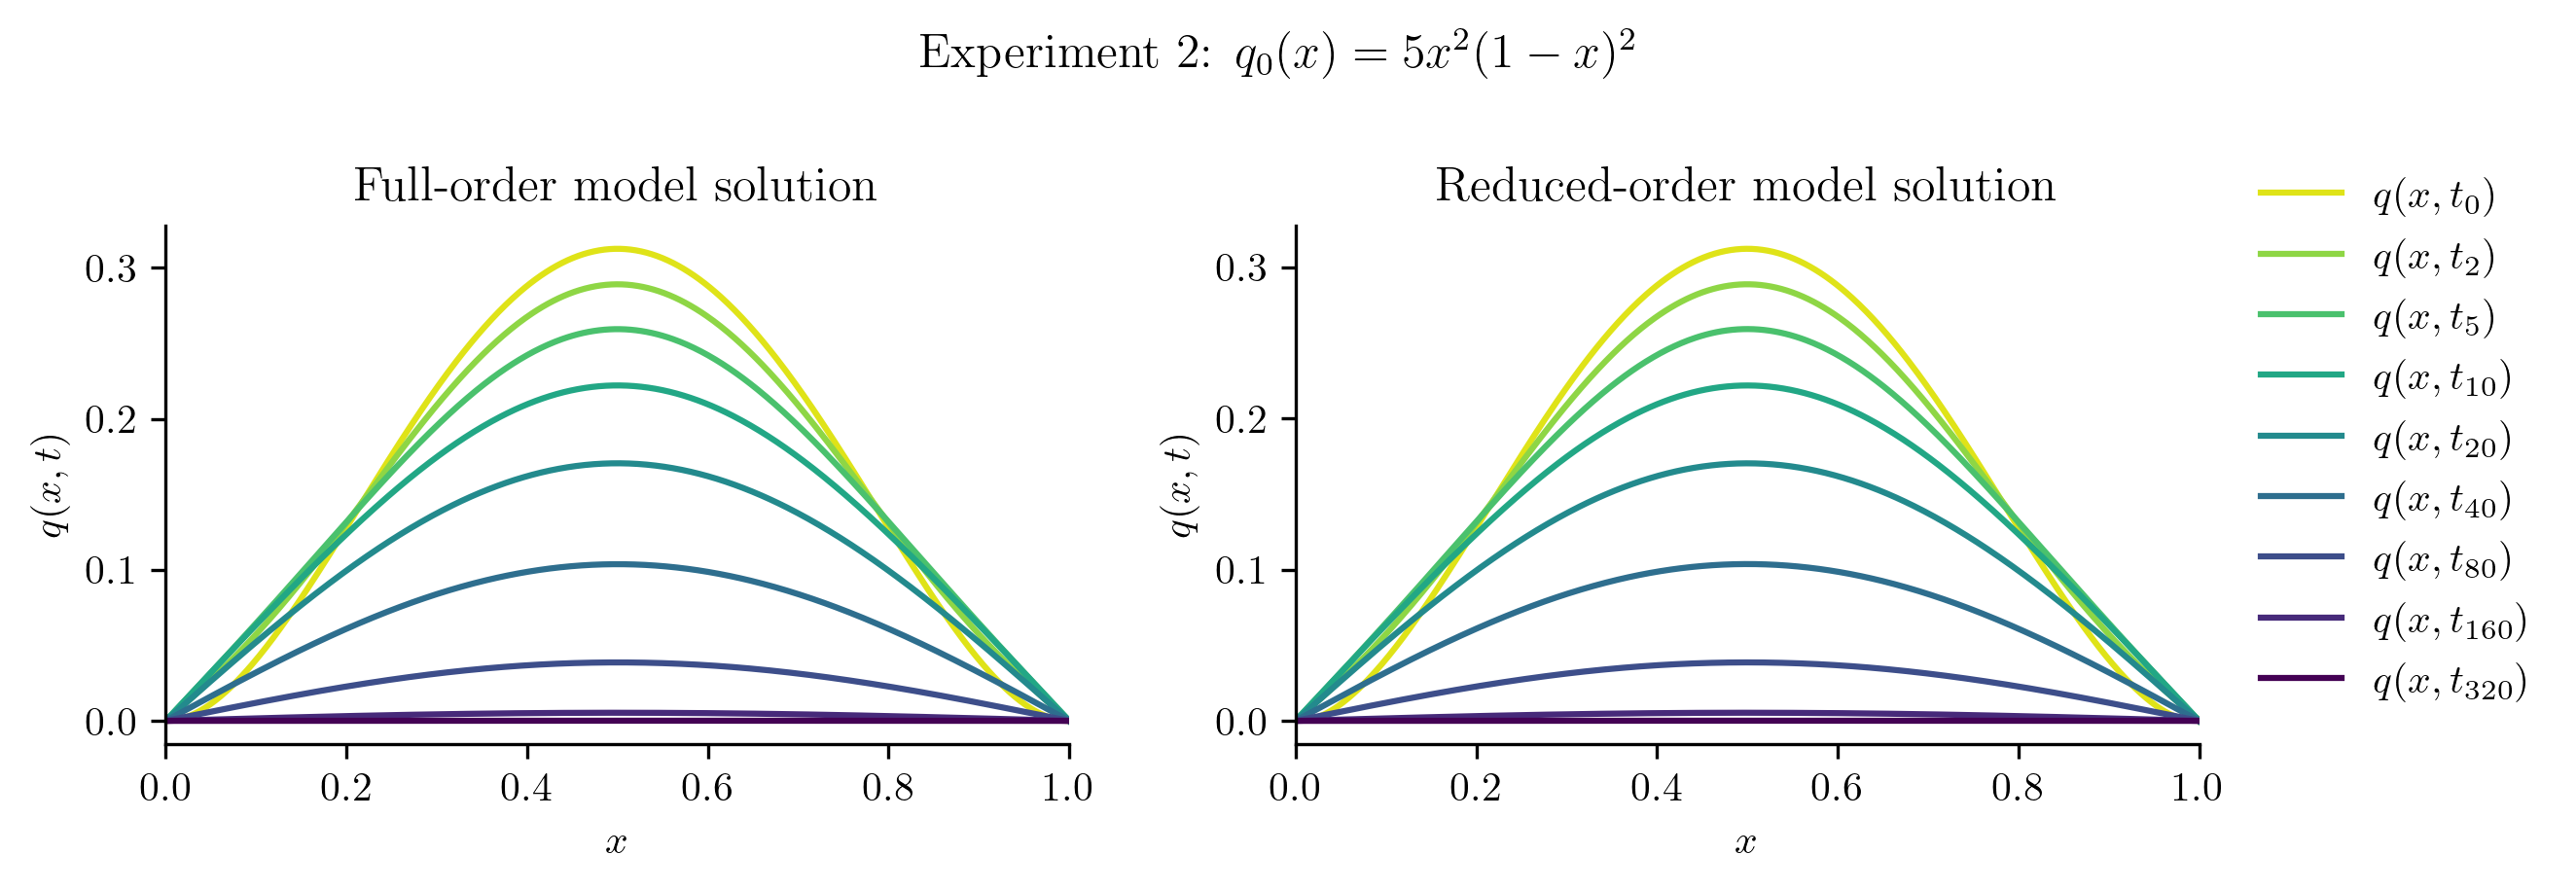

Relative projection error of initial condition: 0.11%
Relative Frobenius-norm ROM error: 0.06%


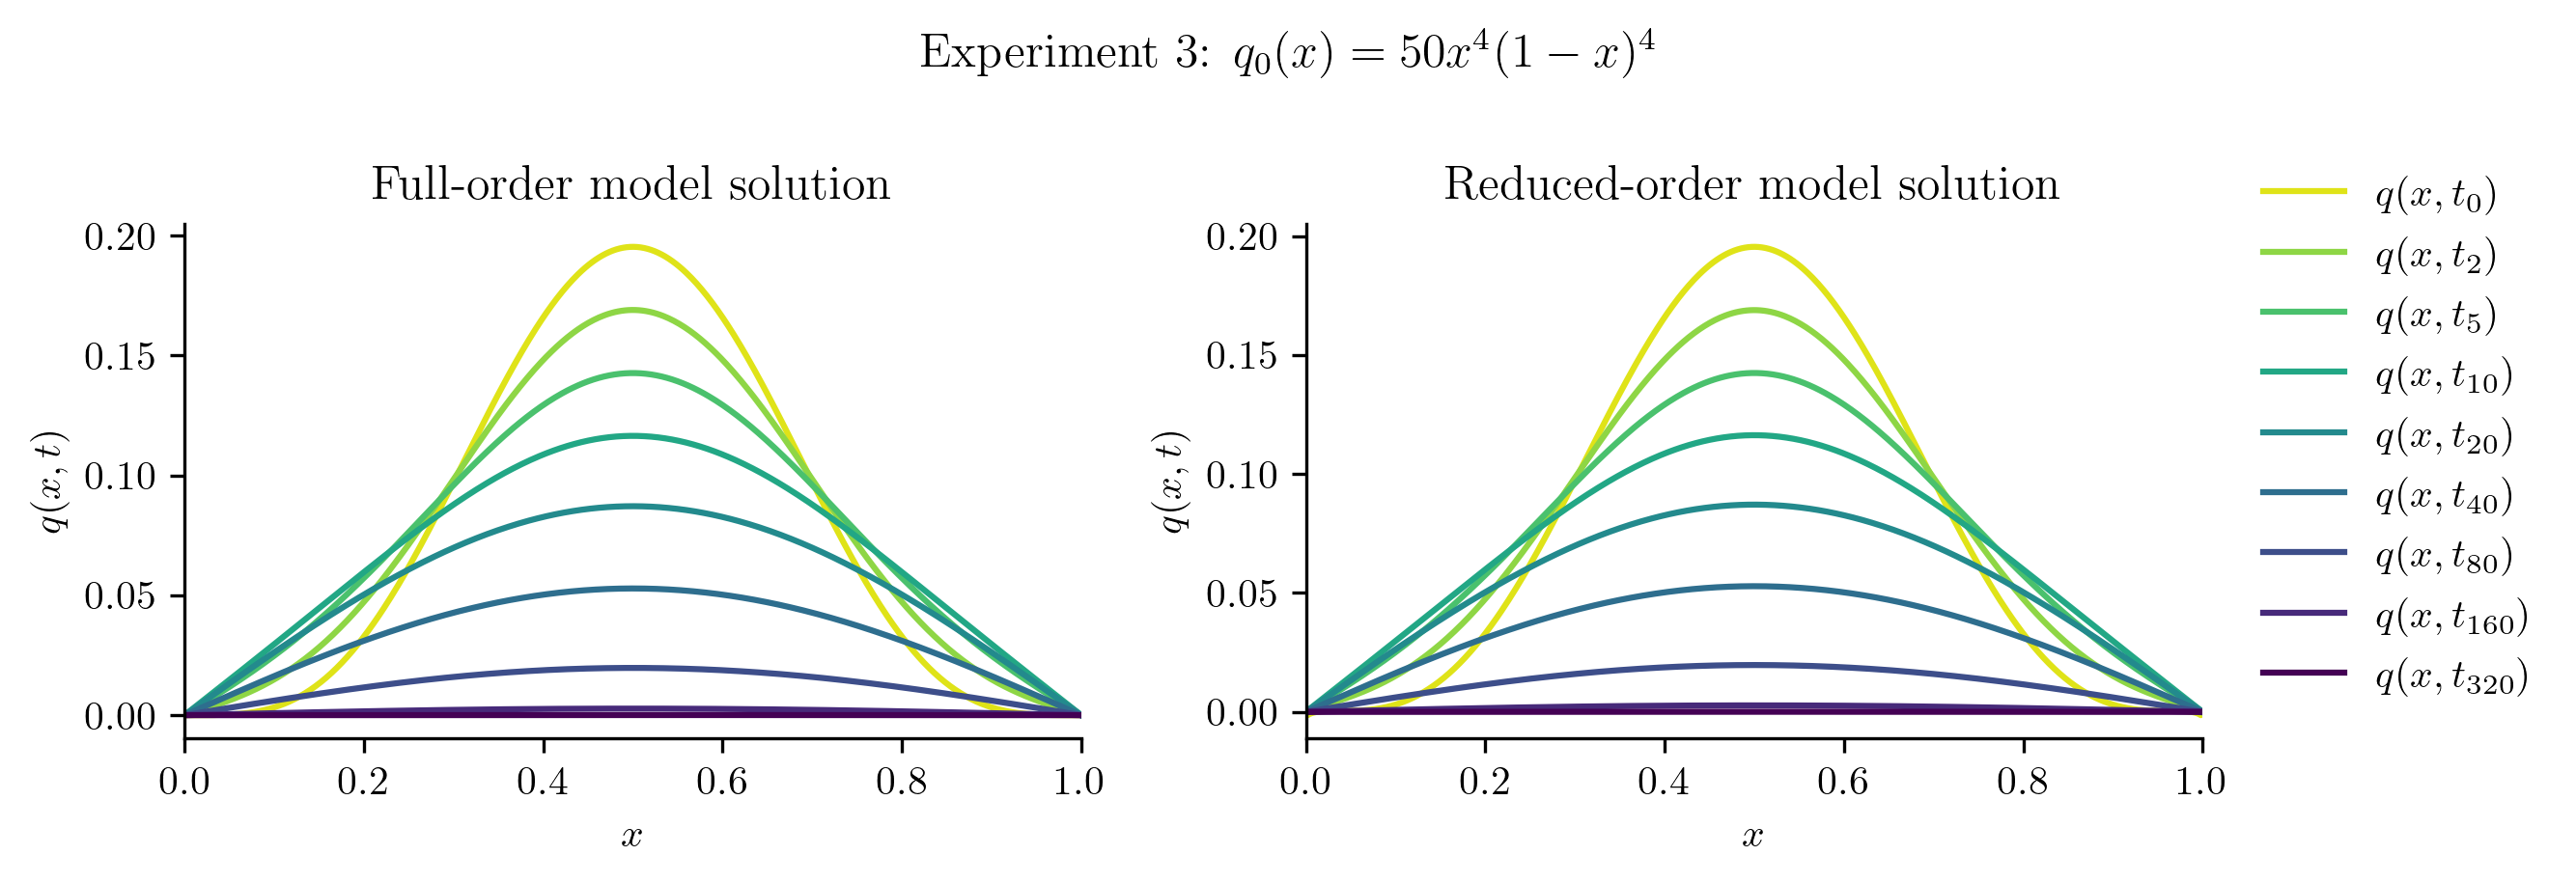

Relative projection error of initial condition: 0.16%
Relative Frobenius-norm ROM error: 0.15%


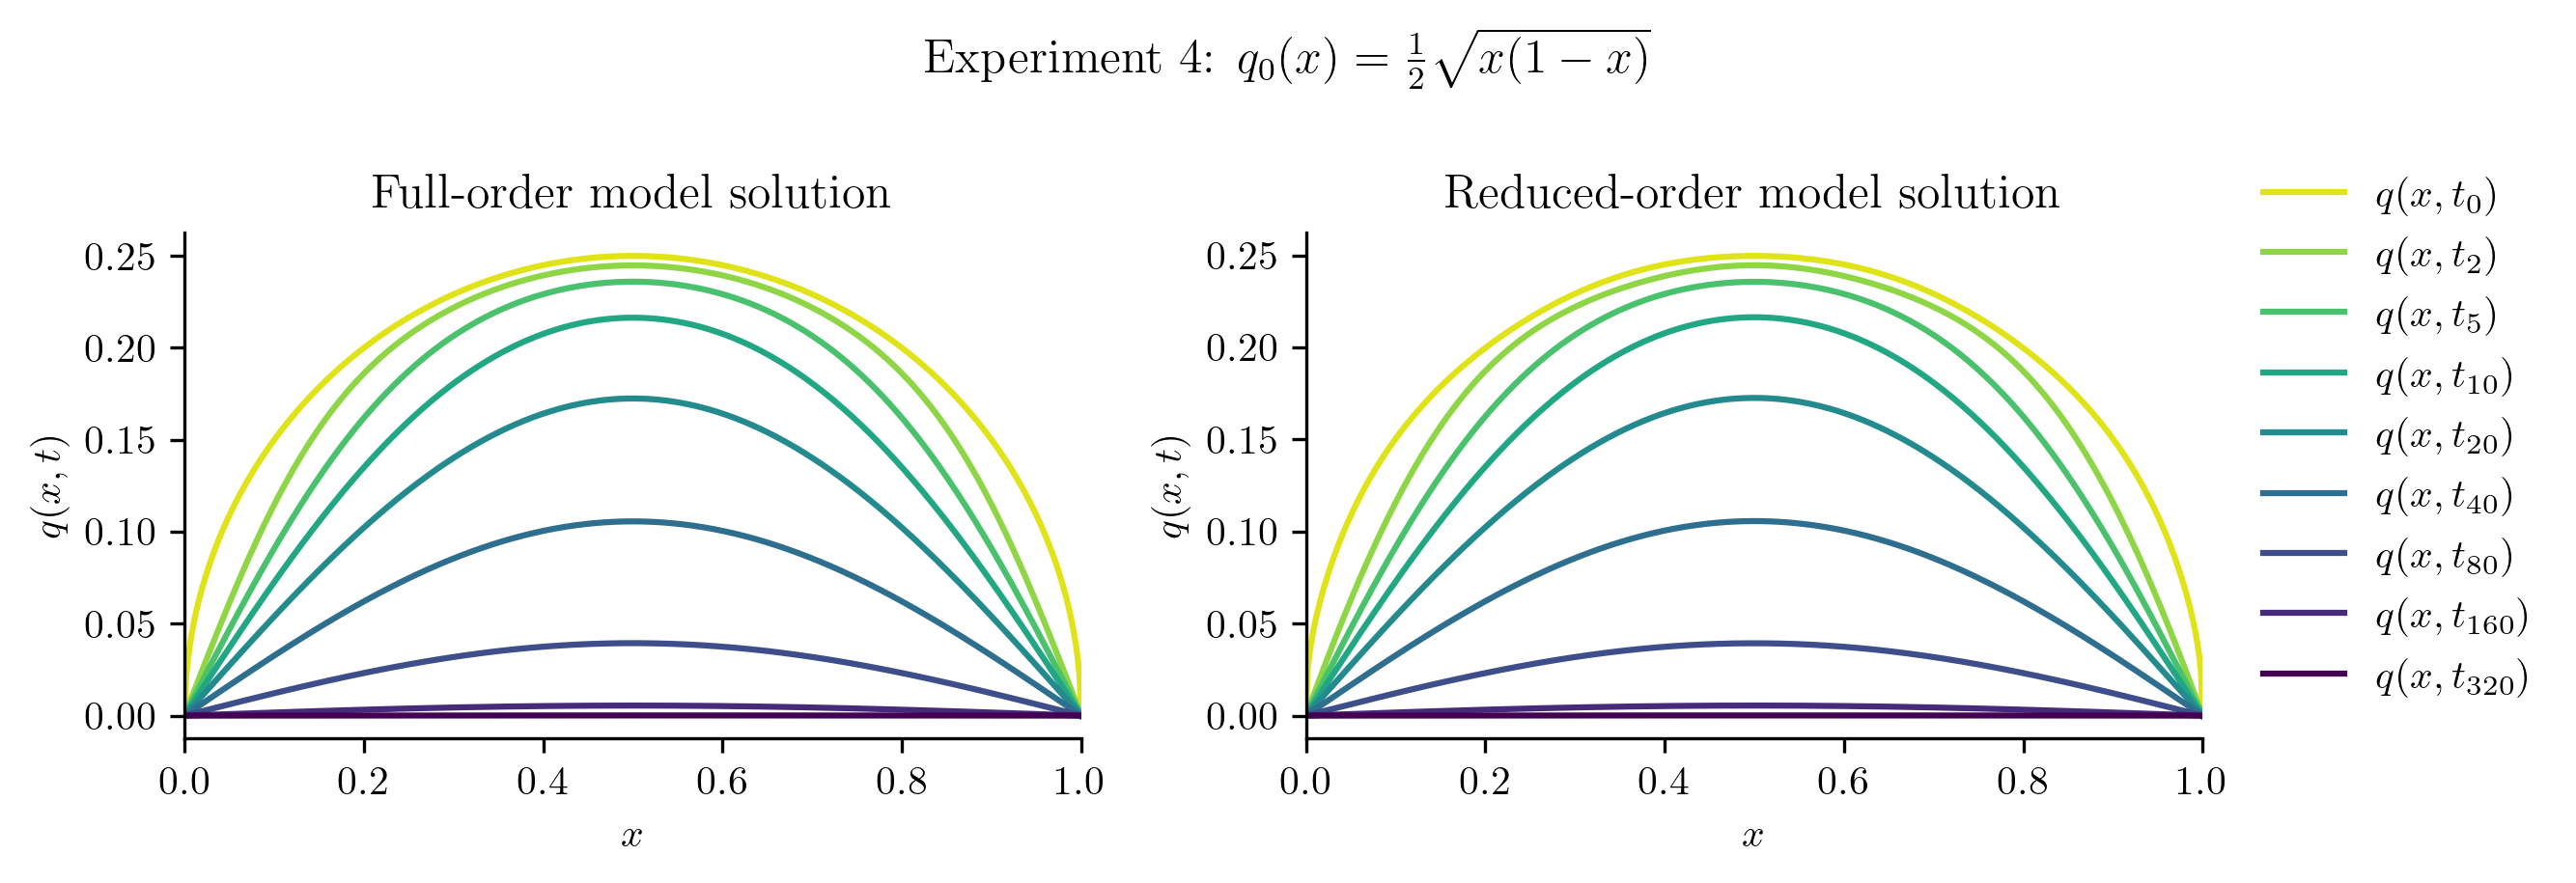

Relative projection error of initial condition: 0.18%
Relative Frobenius-norm ROM error: 0.23%


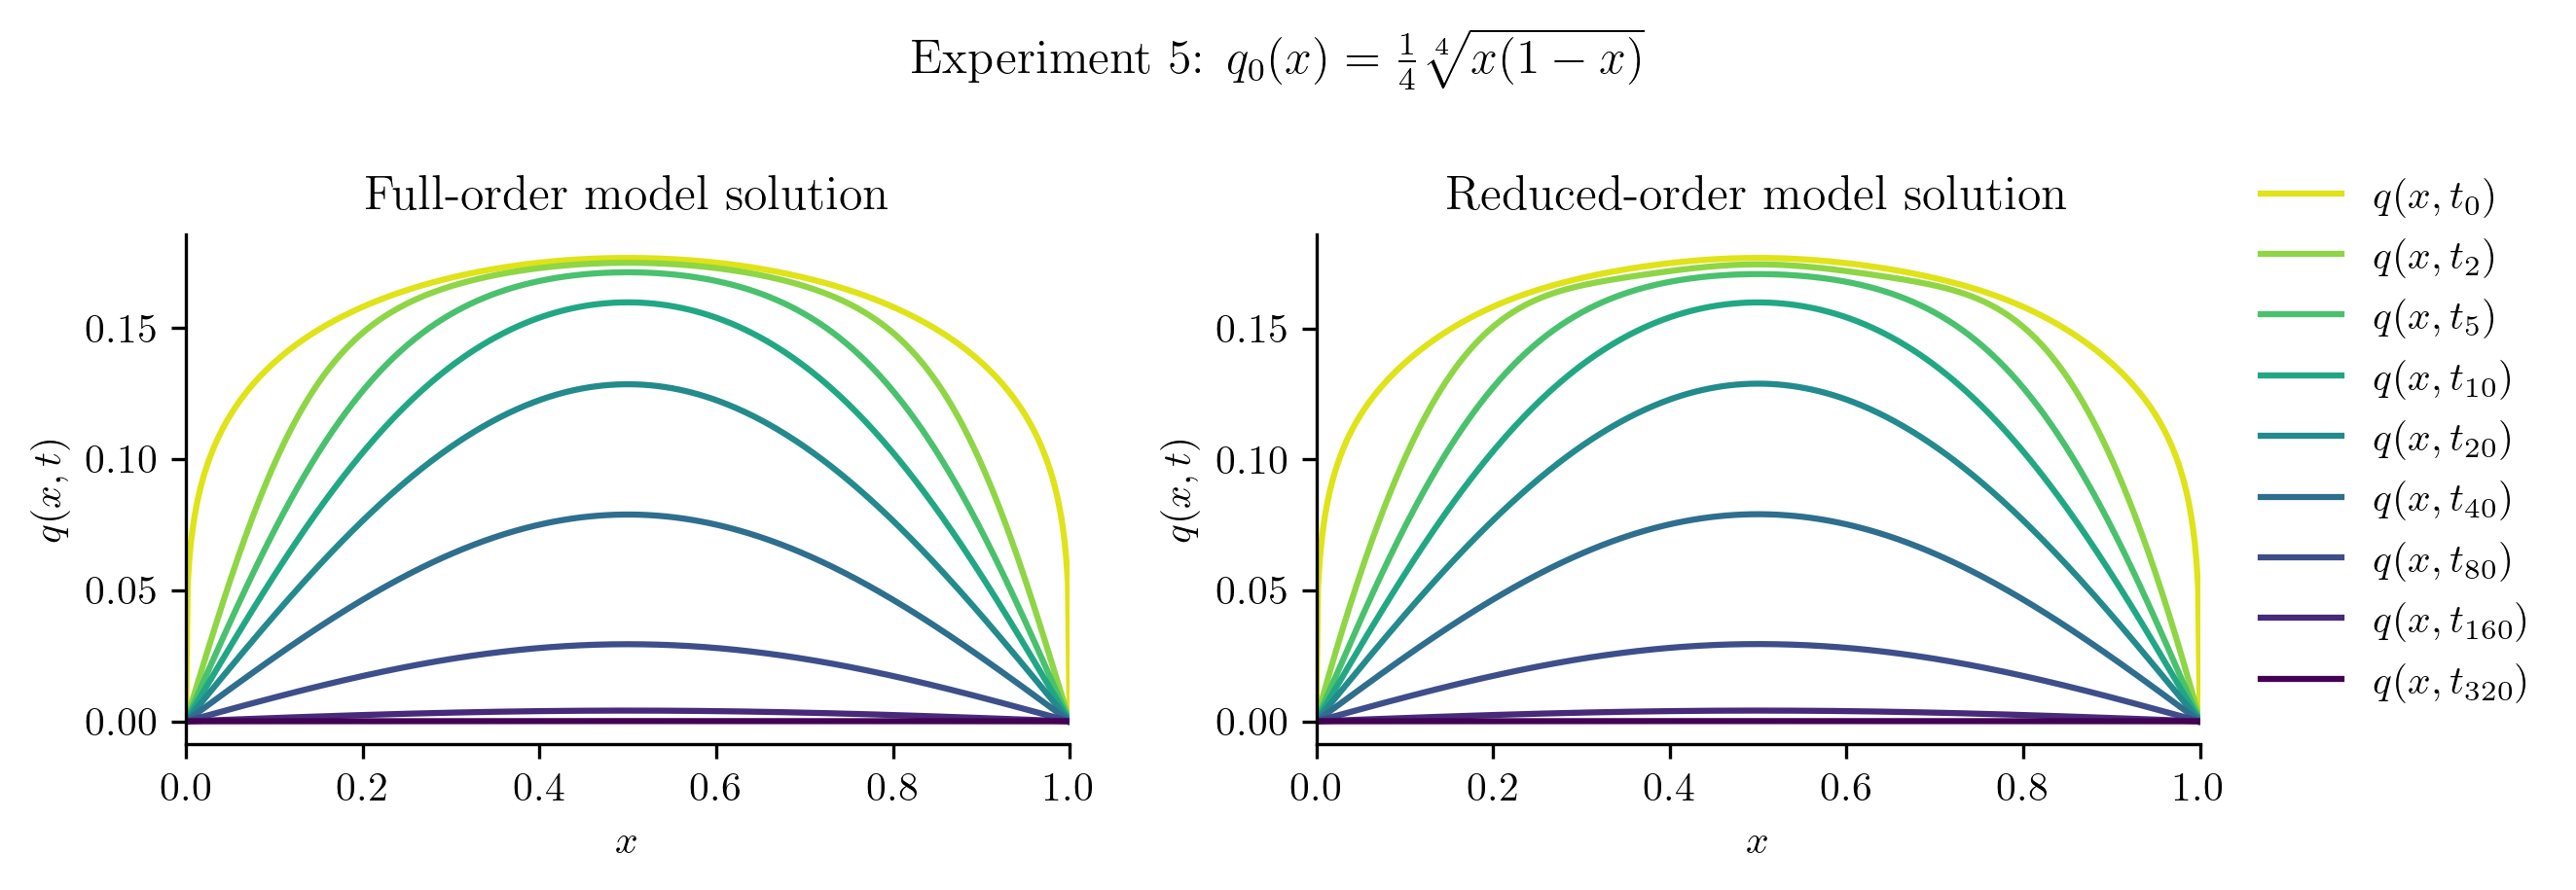

Relative projection error of initial condition: 0.11%
Relative Frobenius-norm ROM error: 0.62%


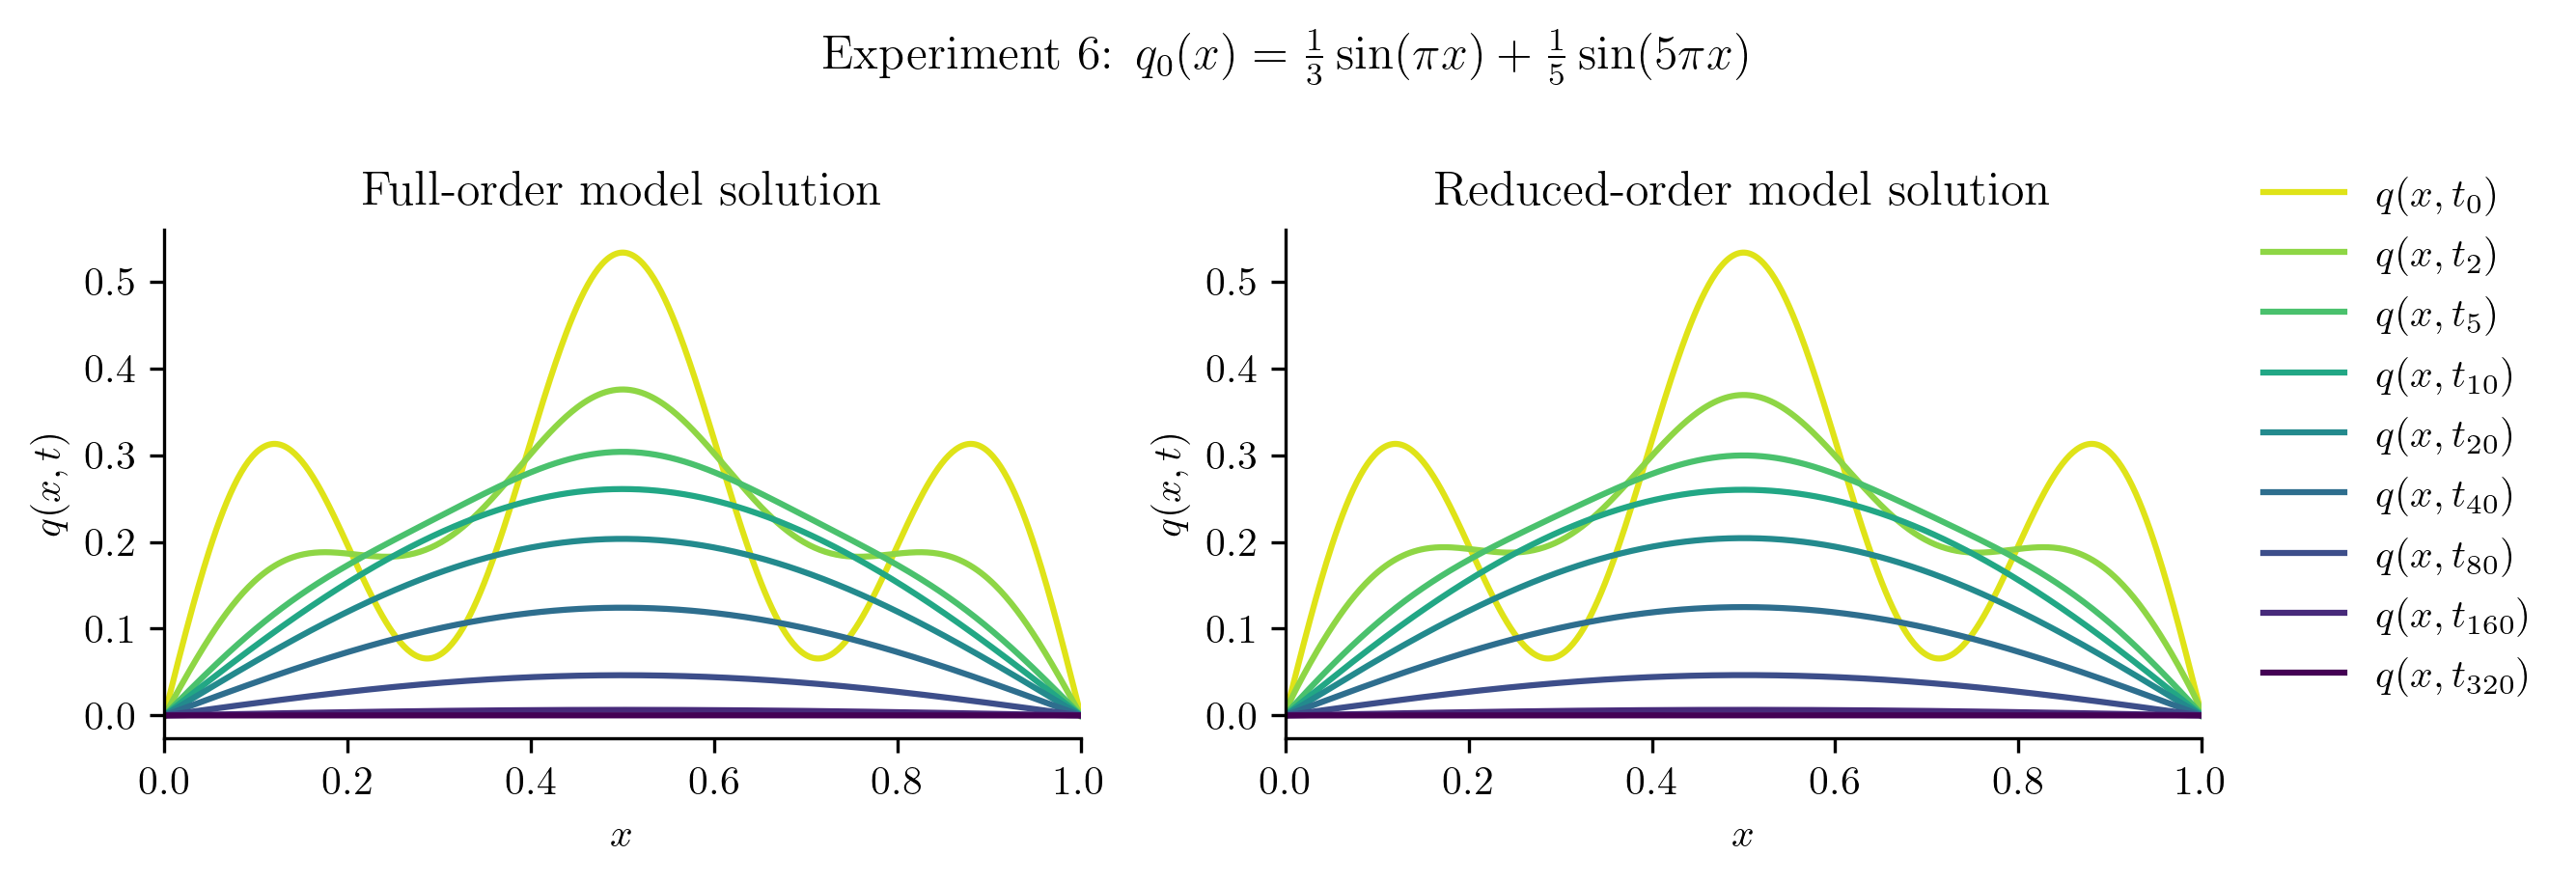

Relative projection error of initial condition: 0.00%
Relative Frobenius-norm ROM error: 1.30%


,Relative projection error of initial condition,Relative Frobenius-norm ROM error
Experiment 1,0.0051%,0.0199%
Experiment 2,0.1062%,0.0614%
Experiment 3,0.1617%,0.1484%
Experiment 4,0.1760%,0.2339%
Experiment 5,0.1109%,0.6230%
Experiment 6,0.0025%,1.2969%


In [ ]:
# Repeat the experiments.
results_new = {}
for i, [q00, title] in enumerate(zip(q0_new, q0_titles)):
    results_new[f"Experiment {i+1:d}"] = test_new_initial_condition(
        q00,
        rom,
        f"Experiment {i+1}: {title}",
    )

# Display results summary.
pd.DataFrame(results_new, index=labels).T

With a more expressive basis, the ROM performance improves significantly.

:::{admonition} No Better than the Basis
:class: tip
This example illustrates a fundamental principle of model reduction: the accuracy of the ROM is limited by the accuracy of the underlying low-dimensional approximation, which in this case is $\q(t) \approx \Vr\qhat(t)$. In other words, a good $\Vr$ is critical in order for the ROM to be accurate and predictive.
:::